# Satellite Intelligence Platform
### Automated Damage Detection using Sentinel-2 Satellite Imagery

**Study areas:** Mariupol · Kharkiv · Bakhmut  
**Time span:** Q1 2021 – Q2 2024  
**Data source:** Microsoft Planetary Computer (Sentinel-2 Level-2A)

---

## Quick Start

### Google Colab
1. Run **the Environment Setup cell** (immediately below) first — it installs all packages and
   creates the required directory structure automatically.
2. Run all remaining cells in order from top to bottom.
3. *(Optional)* Uncomment the `drive.mount` lines in the setup cell to persist downloaded
   satellite data and trained models across Colab sessions.

### Local Jupyter
1. Install dependencies once:
   ```bash
   pip install -r requirements.txt
   ```
2. Launch Jupyter from the **project root** so relative paths (`../data/`, `../models/`) resolve:
   ```bash
   jupyter notebook satellite-damage-detection/notebooks/
   ```

---

## Notebook Sections

| Section | Description |
|---|---|
| **Part 1 - Data Cleaning** | Download Sentinel-2 scenes, apply cloud masking, compute spectral indices |
| **Part 2 - Feature Engineering** | Create damage labels, dataset splits, optional image patches |
| **Part 2b - Rich Features** | Add GLCM texture, distribution statistics, and raw band features |
| **Part 3 - Model Training** | Train Logistic Regression, Random Forest, MLP, and ResNet-50 |
| **Part 4 - Evaluation** | Full metrics, damage maps, UNOSAT comparison, threshold analysis |


## Environment Setup

Run the cell below **once before anything else**. It:
- Installs all required packages (pystac-client, planetary-computer, odc-stac, torchgeo, scikit-image, etc.)
- Creates the expected directory structure (`data/`, `models/`, `results/`)
- In **Google Colab**, automatically sets the working directory so all relative paths work

> **Persisting data across Colab sessions:** Uncomment the `drive.mount` lines to save
> downloaded satellite imagery and trained models to your Google Drive.


In [57]:
import sys, os

%pip install -r ../../requirements.txt

# ── Detect runtime ──────────────────────────────────────────────────────
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Running in: {'Google Colab' if IN_COLAB else 'Local Jupyter / other environment'}")

# ── Install packages ─────────────────────────────────────────────────────
# Satellite data access & geospatial libraries
os.system(f"{sys.executable} -m pip install -q pystac-client planetary-computer 'odc-stac>=0.3' 'odc-geo>=0.4' rioxarray rasterio geopandas")

# Deep learning extras (torch/torchvision are pre-installed in Colab)
os.system(f"{sys.executable} -m pip install -q torchgeo pytorch-lightning")

# Image processing & interactive widgets
os.system(f"{sys.executable} -m pip install -q scikit-image imageio ipywidgets")

print("✓ All packages installed")

# ── Create directory structure ────────────────────────────────────────────
if IN_COLAB:
    # Optional: mount Google Drive to persist data between sessions
    # from google.colab import drive
    # drive.mount('/content/drive')
    # BASE = '/content/drive/MyDrive/satellite-damage-detection'

    BASE = '/content/satellite-damage-detection'
else:
    # Local: resolve BASE as two levels up from this notebook
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))

for _dir in [
    'data/raw', 'data/processed', 'data/patches', 'data/splits',
    'models',
    'results/metrics', 'results/predictions',
    'results/plots', 'results/damage_maps',
    'notebooks',
]:
    os.makedirs(os.path.join(BASE, _dir), exist_ok=True)

if IN_COLAB:
    # Set working directory to notebooks/ so all relative paths (../data/, etc.) resolve
    os.chdir(os.path.join(BASE, 'notebooks'))

print(f"Working directory: {os.getcwd()}")

# Verify key paths
for rel in ['../data/raw', '../data/processed', '../models', '../results/plots']:
    status = "✓" if os.path.isdir(rel) else "⚠ (will be created when data is downloaded)"
    print(f"  {status}  {rel}")

print("✓ Setup complete — run cells in order from top to bottom")


Note: you may need to restart the kernel to use updated packages.
Running in: Local Jupyter / other environment
✓ All packages installed
Working directory: c:\Users\jdlab\OneDrive\Documents\University of the West Indies\Year 3\Semester 2\COMP 3610 Big Data\Project\Satellite-Intelligence-Platform\satellite-damage-detection\notebooks
  ✓  ../data/raw
  ✓  ../data/processed
  ✓  ../models
  ✓  ../results/plots
✓ Setup complete — run cells in order from top to bottom


# Satellite Damage Assessment: Ukraine Conflict Analysis

## Data Cleaning & Feature Engineering

This notebook processes Sentinel-2 satellite imagery from Microsoft Planetary Computer to detect infrastructure damage across Ukrainian conflict zones (Mariupol, Kharkiv, Bakhmut).

**Pipeline:**
1. Download Sentinel-2 Level-2A from Planetary Computer
2. Apply cloud masking
3. Compute spectral indices (NDVI, NDBI, BSI)
4. Save cleaned dataset for modeling


## 1. Setup & Environment

In [58]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

# Setup paths (notebook runs from ../notebooks/)
os.makedirs('../data/raw', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../results/plots', exist_ok=True)

# ============ SPECTRAL INDICES CLASS ============
class SpectralIndices:
    """Compute spectral indices from Sentinel-2 bands."""
    
    @staticmethod
    def ndvi(image):
        """NDVI = (NIR - RED) / (NIR + RED)"""
        red = image[..., 2].astype(float)
        nir = image[..., 3].astype(float)
        return (nir - red) / (nir + red + 1e-8)
    
    @staticmethod
    def ndbi(image):
        """NDBI = (SWIR - NIR) / (SWIR + NIR)"""
        swir = image[..., 4].astype(float)
        nir = image[..., 3].astype(float)
        return (swir - nir) / (swir + nir + 1e-8)
    
    @staticmethod
    def bsi(image):
        """BSI = (SWIR + RED - NIR - BLUE) / (SWIR + RED + NIR + BLUE)"""
        blue = image[..., 0].astype(float)
        red = image[..., 2].astype(float)
        nir = image[..., 3].astype(float)
        swir = image[..., 4].astype(float)
        numerator = swir + red - nir - blue
        denominator = swir + red + nir + blue
        return numerator / (denominator + 1e-8)

# ============ HELPER FUNCTIONS ============
def apply_cloud_mask(image, scl_band):
    """Apply cloud masking using Scene Classification band."""
    valid_pixels = np.isin(scl_band, [4, 5, 6])
    image_masked = image.copy().astype(float)
    image_masked[~valid_pixels] = np.nan
    return image_masked

def normalize_bands(image):
    """Normalize image bands to [0, 1]."""
    return np.clip(image / 10000.0, 0, 1)

def create_patches(image, patch_size=128, stride=64):
    """Extract overlapping patches from image."""
    h, w = image.shape[:2]
    patches = []
    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):
            patches.append(image[i:i+patch_size, j:j+patch_size])
    return patches

print("✓ Environment ready")

✓ Environment ready


## 2. Download Sentinel-2 Data from Microsoft Planetary Computer

In [59]:
# Install required packages (run once)
%pip install pystac-client planetary-computer odc-stac xarray rioxarray

import pystac_client
import planetary_computer
from odc.stac import load
from odc.geo.geom import BoundingBox

print("Connecting to Microsoft Planetary Computer...")

catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=planetary_computer.sign_inplace
)

print("✓ Connected to Planetary Computer")

# Define study areas
study_areas = {
    'Mariupol': [37.40, 46.95, 37.68, 47.15],
    'Kharkiv': [35.80, 49.85, 36.50, 50.10],
    'Bakhmut': [37.70, 48.50, 37.90, 48.65]
}

# UPDATED: Quarterly time periods for more data points
periods = {
    '2021_Q1': '2021-01-01/2021-03-31',
    '2021_Q2': '2021-04-01/2021-06-30',
    '2021_Q3': '2021-07-01/2021-09-30',
    '2021_Q4': '2021-10-01/2021-12-31',
    
    '2022_Q1': '2022-01-01/2022-03-31',
    '2022_Q2': '2022-04-01/2022-06-30',
    '2022_Q3': '2022-07-01/2022-09-30',
    '2022_Q4': '2022-10-01/2022-12-31',
    
    '2023_Q1': '2023-01-01/2023-03-31',
    '2023_Q2': '2023-04-01/2023-06-30',
    '2023_Q3': '2023-07-01/2023-09-30',
    '2023_Q4': '2023-10-01/2023-12-31',
    
    '2024_Q1': '2024-01-01/2024-03-31',
    '2024_Q2': '2024-04-01/2024-06-30',
}

print(f"\nDownloading Sentinel-2 data...")
print(f"Cities: {list(study_areas.keys())}")
print(f"Time periods: {len(periods)} quarters")
print(f"Expected scenes: {len(study_areas) * len(periods)}\\n")

Note: you may need to restart the kernel to use updated packages.
Connecting to Microsoft Planetary Computer...
✓ Connected to Planetary Computer

Cities: ['Mariupol', 'Kharkiv', 'Bakhmut']
Time periods: 14 quarters
Expected scenes: 42\n


## 3. Download and Process Each Scene

In [60]:
def normalize_for_display(band):
    """Normalize a band to 0-1 for display."""
    band = band.astype(float)
    band = np.nan_to_num(band, nan=0)
    band_min = np.percentile(band[band > 0], 2) if np.any(band > 0) else 0
    band_max = np.percentile(band[band > 0], 98) if np.any(band > 0) else 1
    band_norm = (band - band_min) / (band_max - band_min + 1e-8)
    return np.clip(band_norm, 0, 1)

def create_rgb_image(image, bands_indices=[2, 1, 0]):
    """Create RGB image from specific bands for visualization.
    
    Default: Natural color (R=B04, G=B03, B=B02)
    Alternative: False color (R=B08, G=B04, B=B03) - use [3, 2, 1]
    """
    rgb = np.zeros((image.shape[0], image.shape[1], 3))
    for i, band_idx in enumerate(bands_indices):
        rgb[..., i] = normalize_for_display(image[..., band_idx])
    return (rgb * 255).astype(np.uint8)

print("✓ Visualization functions ready")

✓ Visualization functions ready


In [61]:
from odc.geo.geom import box as geo_box

# ── Load existing metadata so already-downloaded scenes are not re-fetched ──
existing_meta = {}
if os.path.exists('../data/raw/metadata.csv'):
    _df = pd.read_csv('../data/raw/metadata.csv')
    for _, _row in _df.iterrows():
        existing_meta[(_row['city'], _row['period'])] = _row.to_dict()
    print(f"Loaded {len(existing_meta)} existing records from metadata.csv")

metadata = []
downloaded_count = 0
skipped_count    = 0
failed_count     = 0

for city, bbox in study_areas.items():
    for period_name, datetime_range in periods.items():

        raw_path     = f'../data/raw/S2_{period_name}_{city}.npy'
        cleaned_path = f'../data/raw/S2_{period_name}_{city}_clean.npy'

        # ── Skip if already downloaded (raw) or already cleaned ───────────
        if os.path.exists(raw_path) or os.path.exists(cleaned_path):
            existing_file = raw_path if os.path.exists(raw_path) else cleaned_path
            print(f"Skipping  {city:10} {period_name}  (already exists: {os.path.basename(existing_file)})")
            skipped_count += 1
            # Restore metadata from the previous run if available
            if (city, period_name) in existing_meta:
                metadata.append(existing_meta[(city, period_name)])
            else:
                # Reconstruct a minimal metadata entry so downstream cells work
                metadata.append({
                    'filename':        existing_file,
                    'city':            city,
                    'period':          period_name,
                    'cloud_cover_pct': 0.0,
                    'scene_id':        'unknown',
                })
            continue

        # ── Download ──────────────────────────────────────────────────────
        try:
            print(f"Searching  {city:10} {period_name}...", end=' ')

            search = catalog.search(
                collections=['sentinel-2-l2a'],
                bbox=bbox,
                datetime=datetime_range,
                query={'eo:cloud_cover': {'lt': 30}}
            )

            items = list(search.get_items())
            if len(items) == 0:
                print("No scenes found")
                continue

            item = items[0]
            print(f"Downloading...", end='')

            clip_box = geo_box(
                left=bbox[0], bottom=bbox[1], right=bbox[2], top=bbox[3],
                crs='epsg:4326'
            )
            data = load(
                [item],
                bands=['B02', 'B03', 'B04', 'B08', 'B11', 'B12', 'SCL'],
                resolution=20,
                geopolygon=clip_box,
                patch_url=planetary_computer.sign_url
            )

            image_array = []
            for band in ['B02', 'B03', 'B04', 'B08', 'B11', 'B12', 'SCL']:
                band_data = data[band].values
                band_data = np.squeeze(band_data)
                image_array.append(band_data)

            image = np.stack(image_array, axis=2)
            np.save(raw_path, image.astype(np.uint16))

            cloud_cover = item.properties.get('eo:cloud_cover', 0)
            metadata.append({
                'filename':        raw_path,
                'city':            city,
                'period':          period_name,
                'cloud_cover_pct': cloud_cover,
                'scene_id':        item.id,
            })

            print(f" ✓")
            downloaded_count += 1

        except Exception as e:
            print(f" ✗ {str(e)[:40]}")
            failed_count += 1

print(f"{'='*60}")
print(f"Downloaded : {downloaded_count} scenes")
print(f"Skipped    : {skipped_count} scenes (already on disk)")
print(f"Failed     : {failed_count} scenes")
print(f"{'='*60}")

if metadata:
    df_raw = pd.DataFrame(metadata)
    df_raw.to_csv('../data/raw/metadata.csv', index=False)
    print(f"{'='*60}")  
    print(f"Metadata saved to: ../data/raw/metadata.csv")
    print(df_raw)


Loaded 42 existing records from metadata.csv
Skipping  Mariupol   2021_Q1  (already exists: S2_2021_Q1_Mariupol_clean.npy)
Skipping  Mariupol   2021_Q2  (already exists: S2_2021_Q2_Mariupol_clean.npy)
Skipping  Mariupol   2021_Q3  (already exists: S2_2021_Q3_Mariupol_clean.npy)
Skipping  Mariupol   2021_Q4  (already exists: S2_2021_Q4_Mariupol_clean.npy)
Skipping  Mariupol   2022_Q1  (already exists: S2_2022_Q1_Mariupol_clean.npy)
Skipping  Mariupol   2022_Q2  (already exists: S2_2022_Q2_Mariupol_clean.npy)
Skipping  Mariupol   2022_Q3  (already exists: S2_2022_Q3_Mariupol_clean.npy)
Skipping  Mariupol   2022_Q4  (already exists: S2_2022_Q4_Mariupol_clean.npy)
Skipping  Mariupol   2023_Q1  (already exists: S2_2023_Q1_Mariupol_clean.npy)
Skipping  Mariupol   2023_Q2  (already exists: S2_2023_Q2_Mariupol_clean.npy)
Skipping  Mariupol   2023_Q3  (already exists: S2_2023_Q3_Mariupol_clean.npy)
Skipping  Mariupol   2023_Q4  (already exists: S2_2023_Q4_Mariupol_clean.npy)
Skipping  Mariupol 

## 4. Cloud Masking & Normalization

In [62]:
# Load metadata
df_raw = pd.read_csv('../data/raw/metadata.csv')

print("Applying cloud mask and normalizing data...")

df_cleaned    = df_raw.copy()
cleaned_count = 0
skipped_count = 0

for idx, row in df_raw.iterrows():
    clean_filename = row['filename'].replace('.npy', '_clean.npy')

    # ── Skip if already cleaned ──────────────────────────────────────────
    if os.path.exists(clean_filename):
        try:
            existing     = np.load(clean_filename)
            valid_ratio  = np.isfinite(existing).sum() / existing.size * 100
        except Exception:
            valid_ratio  = 0.0
        df_cleaned.loc[idx, 'valid_pixels_pct'] = valid_ratio
        df_cleaned.loc[idx, 'cleaned_filename'] = clean_filename
        print(f"  Skipping  {os.path.basename(clean_filename)}  (already cleaned)")
        skipped_count += 1
        continue

    # ── Clean the raw file ────────────────────────────────────────────────
    try:
        image    = np.load(row['filename'])
        spectral = image[..., :6].astype(np.float32)
        scl_band = image[..., 6].astype(int)

        spectral_masked     = apply_cloud_mask(spectral, scl_band)
        spectral_normalized = spectral_masked / 10000.0

        np.save(clean_filename, spectral_normalized.astype(np.float32))

        # Delete the raw uint16 file — no longer needed once cleaned
        try:
            os.remove(row['filename'])
        except OSError:
            pass

        valid_ratio = np.isfinite(spectral_normalized).sum() / spectral_normalized.size * 100
        df_cleaned.loc[idx, 'valid_pixels_pct'] = valid_ratio
        df_cleaned.loc[idx, 'cleaned_filename'] = clean_filename

        cleaned_count += 1

    except Exception as e:
        print(f"Error processing {row['filename']}: {e}")
        continue

df_cleaned.to_csv('../data/processed/metadata_cleaned.csv', index=False)

print(f"✓ Cleaned  : {cleaned_count} scenes")
print(f"✓ Skipped  : {skipped_count} scenes (already on disk)")
print(f"Average valid pixels: {df_cleaned['valid_pixels_pct'].mean():.1f}%")
print(f"Cleaned metadata saved to: ../data/processed/metadata_cleaned.csv")


Applying cloud mask and normalizing data...
  Skipping  S2_2021_Q1_Mariupol_clean.npy  (already cleaned)
  Skipping  S2_2021_Q2_Mariupol_clean.npy  (already cleaned)
  Skipping  S2_2021_Q3_Mariupol_clean.npy  (already cleaned)
  Skipping  S2_2021_Q4_Mariupol_clean.npy  (already cleaned)
  Skipping  S2_2022_Q1_Mariupol_clean.npy  (already cleaned)
  Skipping  S2_2022_Q2_Mariupol_clean.npy  (already cleaned)
  Skipping  S2_2022_Q3_Mariupol_clean.npy  (already cleaned)
  Skipping  S2_2022_Q4_Mariupol_clean.npy  (already cleaned)
  Skipping  S2_2023_Q1_Mariupol_clean.npy  (already cleaned)
  Skipping  S2_2023_Q2_Mariupol_clean.npy  (already cleaned)
  Skipping  S2_2023_Q3_Mariupol_clean.npy  (already cleaned)
  Skipping  S2_2023_Q4_Mariupol_clean.npy  (already cleaned)
  Skipping  S2_2024_Q1_Mariupol_clean.npy  (already cleaned)
  Skipping  S2_2024_Q2_Mariupol_clean.npy  (already cleaned)
  Skipping  S2_2021_Q1_Kharkiv_clean.npy  (already cleaned)
  Skipping  S2_2021_Q2_Kharkiv_clean.npy  

## 5. Compute Spectral Indices

In [63]:
# Load metadata with the new format
df_cleaned = pd.read_csv('../data/processed/metadata_cleaned.csv')

print("Computing spectral indices (NDVI, NDBI, BSI)...\n")

si = SpectralIndices()
indices_data = []

for idx, row in df_cleaned.iterrows():
    try:
        # Load cleaned scene
        image = np.load(row['cleaned_filename'])
        
        # Compute indices
        ndvi = si.ndvi(image)
        ndbi = si.ndbi(image)
        bsi = si.bsi(image)
        
        # Extract year and period from filename
        # Format: ../data/processed/S2_2021_Q1_Mariupol_clean.npy
        filename_parts = row['cleaned_filename'].split('_')
        year = int(filename_parts[1])  # 2021, 2022, etc.
        quarter = filename_parts[2]     # Q1, Q2, Q3, Q4
        period = f"{year}_{quarter}"    # 2021_Q1, 2022_Q2, etc.
        
        # Calculate statistics
        indices_data.append({
            'filename': row['cleaned_filename'],
            'city': row['city'],
            'period': period,
            'year': year,
            'quarter': quarter,
            'cloud_cover_pct': row['cloud_cover_pct'],
            'ndvi_mean': np.nanmean(ndvi),
            'ndvi_std': np.nanstd(ndvi),
            'ndvi_min': np.nanmin(ndvi),
            'ndvi_max': np.nanmax(ndvi),
            'ndbi_mean': np.nanmean(ndbi),
            'ndbi_std': np.nanstd(ndbi),
            'ndbi_min': np.nanmin(ndbi),
            'ndbi_max': np.nanmax(ndbi),
            'bsi_mean': np.nanmean(bsi),
            'bsi_std': np.nanstd(bsi),
            'bsi_min': np.nanmin(bsi),
            'bsi_max': np.nanmax(bsi),
            'valid_pixels_pct': row['valid_pixels_pct']
        })
        
    except Exception as e:
        print(f"Error computing indices for {row['cleaned_filename']}: {e}")
        continue

# Create final dataset
if indices_data:
    df_indices = pd.DataFrame(indices_data)
    df_indices.to_csv('../data/processed/sentinel2_clean_2021_2024.csv', index=False)
    
    print(f"✓ Computed indices for {len(indices_data)} scenes")
    print(f"\nFinal dataset saved to: ../data/processed/sentinel2_clean_2021_2024.csv")
    print(f"\nDataset shape: {df_indices.shape}")
    print(f"\nFirst few rows:")
    print(df_indices.head(10).to_string())
    print(f"\nStatistics:")
    print(df_indices[['ndvi_mean', 'ndbi_mean', 'bsi_mean']].describe().round(3))
else:
    print("ERROR: No data was processed!")
    print("Make sure ../data/processed/metadata_cleaned.csv exists")

Computing spectral indices (NDVI, NDBI, BSI)...

✓ Computed indices for 42 scenes

Final dataset saved to: ../data/processed/sentinel2_clean_2021_2024.csv

Dataset shape: (42, 19)

First few rows:
                                    filename      city   period  year quarter  cloud_cover_pct  ndvi_mean  ndvi_std  ndvi_min  ndvi_max  ndbi_mean  ndbi_std  ndbi_min  ndbi_max  bsi_mean   bsi_std   bsi_min   bsi_max  valid_pixels_pct
0  ../data/raw/S2_2021_Q1_Mariupol_clean.npy  Mariupol  2021_Q1  2021      Q1         1.579593  -0.453026  0.596125 -0.996055  0.983870   0.109403  0.254780 -0.997518  0.997870 -0.119291  0.378911 -0.981982  0.995749         88.916969
1  ../data/raw/S2_2021_Q2_Mariupol_clean.npy  Mariupol  2021_Q2  2021      Q2        19.394487   0.116655  0.408689 -0.495601  0.964457  -0.206263  0.088779 -0.630851  0.825911 -0.098531  0.089352 -0.533627  0.684380         55.812232
2  ../data/raw/S2_2021_Q3_Mariupol_clean.npy  Mariupol  2021_Q3  2021      Q3         0.462978  -0

## 6. Data Quality Summary

In [64]:
print("DATA QUALITY SUMMARY")
print("="*70)

print(f"\n1. Temporal Coverage:")
for year in sorted(df_indices['year'].unique()):
    year_data = df_indices[df_indices['year'] == year]
    count = len(year_data)
    quarters = sorted(year_data['quarter'].unique())
    print(f"   {year}: {count} scenes - {', '.join(quarters)}")

print(f"\n2. Geographic Coverage:")
for city in sorted(df_indices['city'].unique()):
    count = (df_indices['city'] == city).sum()
    print(f"   {city}: {count} scenes")

print(f"\n3. Data Quality Metrics:")
print(f"   Average cloud cover: {df_indices['cloud_cover_pct'].mean():.1f}%")
print(f"   Average valid pixels: {df_indices['valid_pixels_pct'].mean():.1f}%")
print(f"   Missing values: {df_indices.isnull().sum().sum()}")

print(f"\n4. Spectral Index Ranges:")
print(f"   NDVI: [{df_indices['ndvi_mean'].min():.3f}, {df_indices['ndvi_mean'].max():.3f}]")
print(f"   NDBI: [{df_indices['ndbi_mean'].min():.3f}, {df_indices['ndbi_mean'].max():.3f}]")
print(f"   BSI:  [{df_indices['bsi_mean'].min():.3f}, {df_indices['bsi_mean'].max():.3f}]")

print(f"\n5. Total Dataset:")
print(f"   Scenes: {len(df_indices)}")
print(f"   Time span: {df_indices['year'].min()} to {df_indices['year'].max()}")
print(f"   Quarters: {df_indices['quarter'].nunique()}")

print(f"\n" + "="*70)
print("✓ Data cleaning complete!")

DATA QUALITY SUMMARY

1. Temporal Coverage:
   2021: 12 scenes - Q1, Q2, Q3, Q4
   2022: 12 scenes - Q1, Q2, Q3, Q4
   2023: 12 scenes - Q1, Q2, Q3, Q4
   2024: 6 scenes - Q1, Q2

2. Geographic Coverage:
   Bakhmut: 14 scenes
   Kharkiv: 14 scenes
   Mariupol: 14 scenes

3. Data Quality Metrics:
   Average cloud cover: 10.4%
   Average valid pixels: 54.0%
   Missing values: 0

4. Spectral Index Ranges:
   NDVI: [-0.453, 0.695]
   NDBI: [-0.510, 0.211]
   BSI:  [-0.290, 0.182]

5. Total Dataset:
   Scenes: 42
   Time span: 2021 to 2024
   Quarters: 4

✓ Data cleaning complete!


## 7. Visualization

✓ Visualization saved to: ../results/plots/spectral_analysis.png


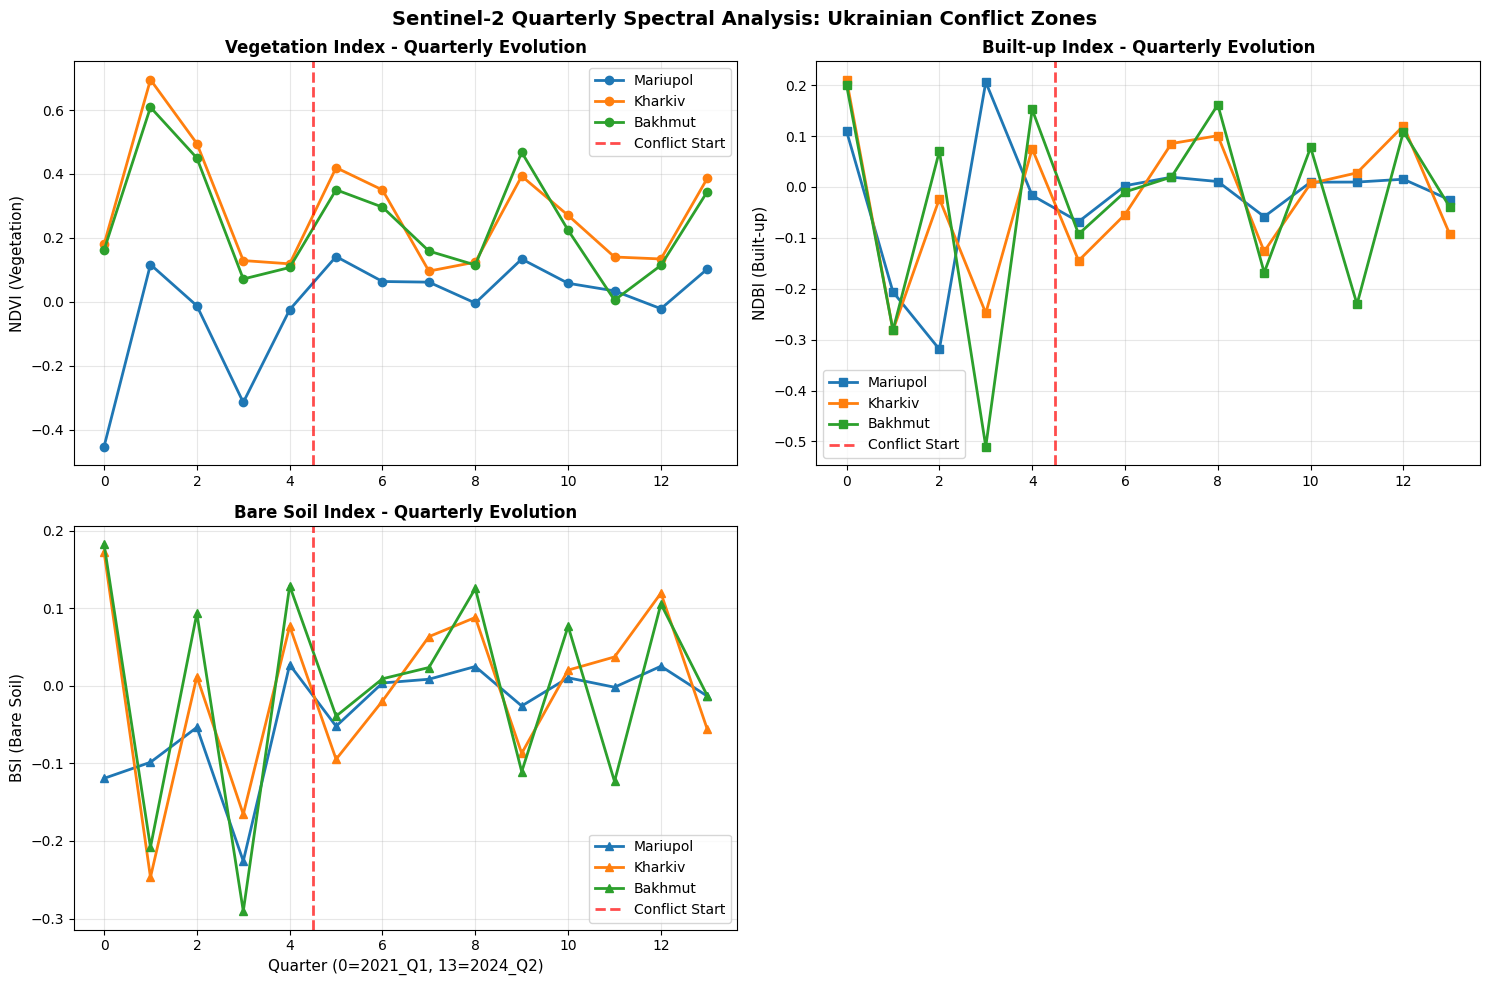

In [65]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for city in df_indices['city'].unique():
    city_data = df_indices[df_indices['city'] == city].sort_values('period')
    
    # Create numeric x-axis for quarters
    x = range(len(city_data))
    
    axes[0, 0].plot(x, city_data['ndvi_mean'], marker='o', label=city, linewidth=2)
    axes[0, 1].plot(x, city_data['ndbi_mean'], marker='s', label=city, linewidth=2)
    axes[1, 0].plot(x, city_data['bsi_mean'], marker='^', label=city, linewidth=2)

# Mark conflict start (2022-02-24 = around early 2022 Q1)
# That's around index 4-5 (after 2021 Q1, Q2, Q3, Q4, and early 2022)
conflict_quarter_index = 4.5  # Between 2021 Q4 and 2022 Q2

for ax in [axes[0, 0], axes[0, 1], axes[1, 0]]:
    ax.axvline(conflict_quarter_index, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Conflict Start')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

axes[0, 0].set_ylabel('NDVI (Vegetation)', fontsize=11)
axes[0, 0].set_title('Vegetation Index - Quarterly Evolution', fontsize=12, fontweight='bold')

axes[0, 1].set_ylabel('NDBI (Built-up)', fontsize=11)
axes[0, 1].set_title('Built-up Index - Quarterly Evolution', fontsize=12, fontweight='bold')

axes[1, 0].set_ylabel('BSI (Bare Soil)', fontsize=11)
axes[1, 0].set_xlabel('Quarter (0=2021_Q1, 13=2024_Q2)', fontsize=11)
axes[1, 0].set_title('Bare Soil Index - Quarterly Evolution', fontsize=12, fontweight='bold')

axes[1, 1].axis('off')

plt.suptitle('Sentinel-2 Quarterly Spectral Analysis: Ukrainian Conflict Zones', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/spectral_analysis.png', dpi=150, bbox_inches='tight')
print("✓ Visualization saved to: ../results/plots/spectral_analysis.png")
plt.show()

## 8. Summary


FINAL CLEANED DATASET SUMMARY
                                 filename     city  period  year quarter  cloud_cover_pct  ndvi_mean  ndvi_std  ndvi_min  ndvi_max  ndbi_mean  ndbi_std  ndbi_min  ndbi_max  bsi_mean  bsi_std   bsi_min  bsi_max  valid_pixels_pct
../data/raw/S2_2021_Q1_Mariupol_clean.npy Mariupol 2021_Q1  2021      Q1         1.579593  -0.453026  0.596125 -0.996055  0.983870   0.109403  0.254780 -0.997518  0.997870 -0.119291 0.378911 -0.981982 0.995749         88.916969
../data/raw/S2_2021_Q2_Mariupol_clean.npy Mariupol 2021_Q2  2021      Q2        19.394487   0.116655  0.408689 -0.495601  0.964457  -0.206263  0.088779 -0.630851  0.825911 -0.098531 0.089352 -0.533627 0.684380         55.812232
../data/raw/S2_2021_Q3_Mariupol_clean.npy Mariupol 2021_Q3  2021      Q3         0.462978  -0.012504  0.460326 -1.000000  0.999975  -0.318961  0.332724 -0.980391  1.000000 -0.053538 0.145230 -0.604551 0.899441         96.749117
../data/raw/S2_2021_Q4_Mariupol_clean.npy Mariupol 2021_Q

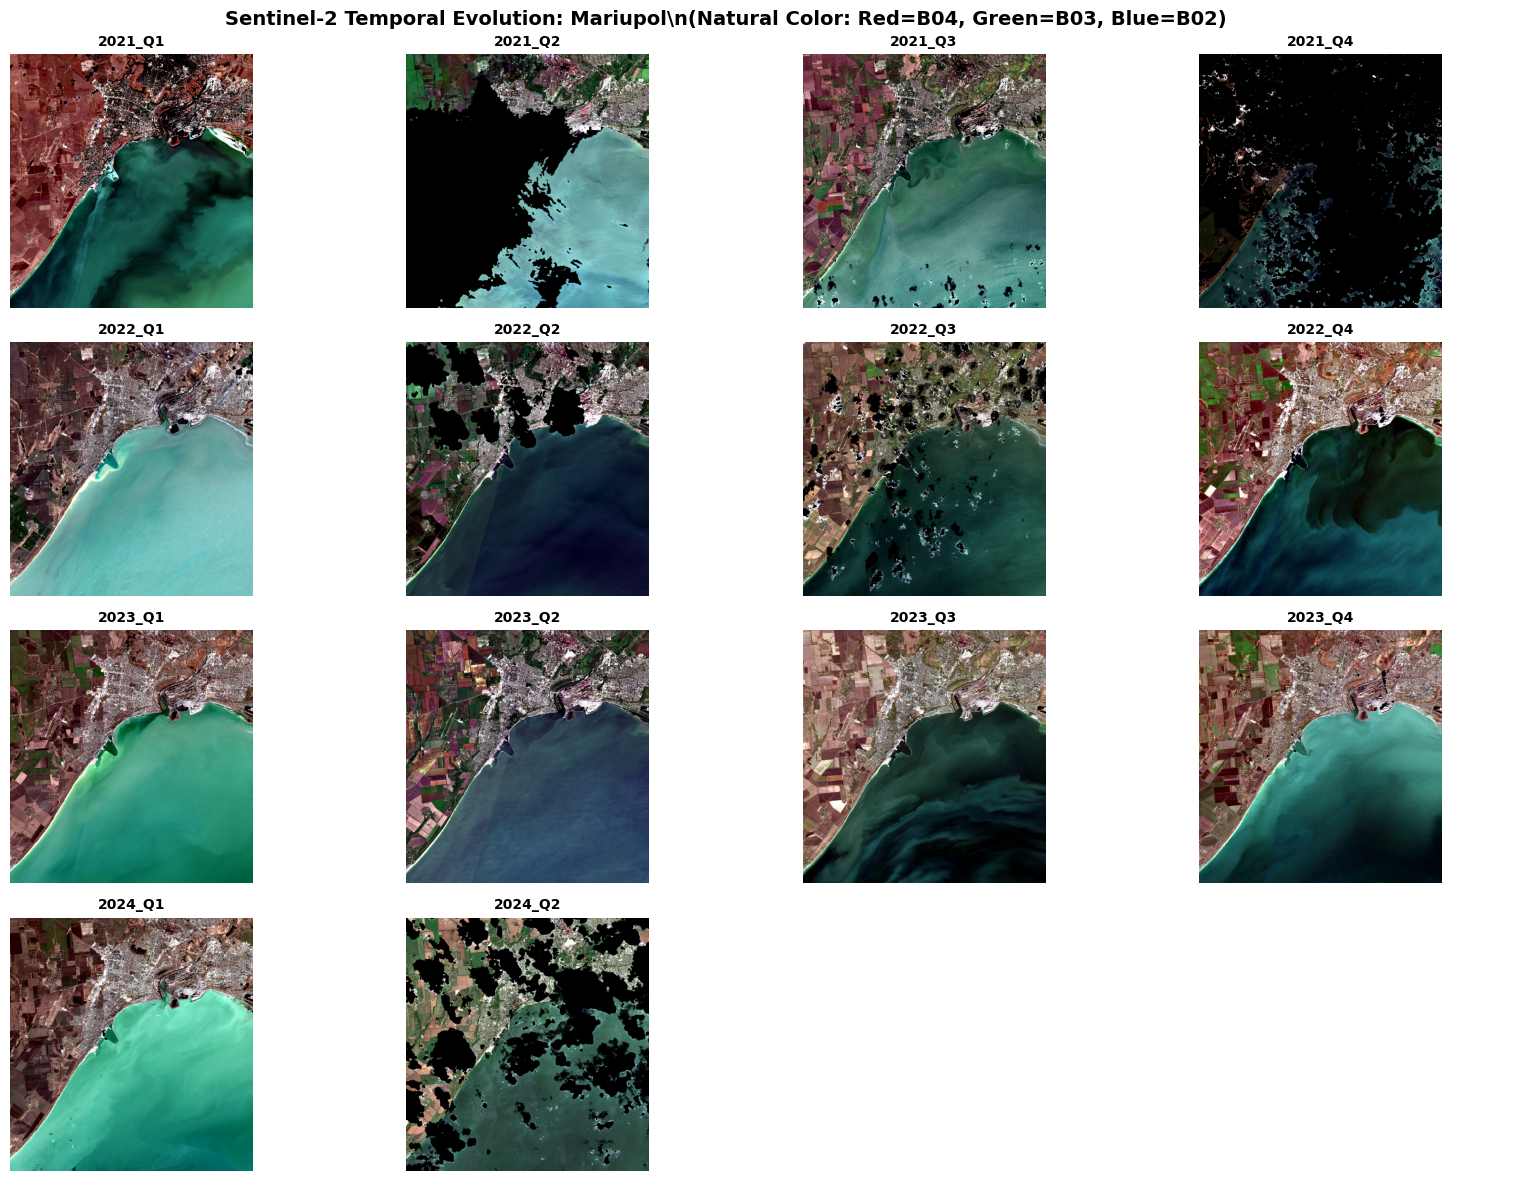

In [66]:
import matplotlib.pyplot as plt
from PIL import Image

print("\n" + "="*70)
print("FINAL CLEANED DATASET SUMMARY")
print("="*70)
print(df_indices.to_string(index=False))

print(f"\n✓ Main output: ../data/processed/sentinel2_clean_2021_2024.csv")
print(f"✓ Total scenes: {len(df_indices)}")
print(f"✓ Features: {df_indices.shape[1]}")
print(f"\nNext step: Move to Notebook 2 (Feature Engineering)")
print("="*70)

# Load cleaned images and display them
print("\\nLoading and displaying cleaned Sentinel-2 imagery...\\n")

# Pick one city (e.g., Mariupol)
city_to_display = 'Mariupol'
city_files = [f for f in os.listdir('../data/raw/') 
              if f.startswith(f'S2_') and city_to_display in f and '_clean.npy' in f]
city_files.sort()

print(f"Found {len(city_files)} scenes for {city_to_display}")

# Create a large grid showing all time periods
n_cols = 4
n_rows = (len(city_files) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

for idx, filename in enumerate(city_files):
    filepath = os.path.join('../data/raw/', filename)
    image = np.load(filepath)
    
    # Create RGB image (natural color)
    rgb = create_rgb_image(image, bands_indices=[2, 1, 0])
    
    axes[idx].imshow(rgb)
    
    # Extract date from filename (e.g., S2_2021_Q1_Mariupol_clean.npy)
    period = filename.split('_')[1] + '_' + filename.split('_')[2]
    axes[idx].set_title(f'{period}', fontsize=10, fontweight='bold')
    axes[idx].axis('off')

# Hide empty subplots
for idx in range(len(city_files), len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Sentinel-2 Temporal Evolution: {city_to_display}\\n(Natural Color: Red=B04, Green=B03, Blue=B02)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/temporal_grid.png', dpi=150, bbox_inches='tight')
print(f"✓ Temporal grid saved to: ../results/plots/temporal_grid.png")
plt.show()

## 9. Create Animated GIF

In [67]:
import threading
import time
import io
from PIL import Image, ImageDraw
from IPython.display import Image as IPImage
import ipywidgets as widgets
from IPython.display import display, HTML

print("Creating animated GIF and interactive viewer...\n")

city_to_animate = 'Mariupol'  # Change to 'Kharkiv' or 'Bakhmut' if desired

# Find all scenes for this city
city_files = [f for f in os.listdir('../data/raw/') 
              if f.startswith(f'S2_') and city_to_animate in f and '_clean.npy' in f]
city_files.sort()

print(f"Creating interactive viewer from {len(city_files)} scenes for {city_to_animate}...\n")

frames = []
frame_labels = []

for filename in city_files:
    filepath = os.path.join('../data/raw/', filename)
    image = np.load(filepath)
    
    # Create RGB image (natural color)
    rgb = create_rgb_image(image, bands_indices=[2, 1, 0])
    
    # Convert to PIL Image
    pil_image = Image.fromarray(rgb)
    
    # Add text with date
    draw = ImageDraw.Draw(pil_image)
    period = filename.split('_')[1] + ' ' + filename.split('_')[2]
    frame_labels.append(period)
    
    # Draw semi-transparent background for text
    draw.rectangle([0, 0, 250, 60], fill=(0, 0, 0, 200))
    draw.text((10, 10), period, fill='white', font=None)
    draw.text((10, 35), f'{city_to_animate}', fill='yellow', font=None)
    
    frames.append(pil_image)

print(f"✓ Prepared {len(frames)} frames\n")

# Pre-render frames to PNG bytes for thread-safe display
frame_bytes = []
for _f in frames:
    _buf = io.BytesIO()
    _f.save(_buf, format='PNG')
    frame_bytes.append(_buf.getvalue())

# ============ CREATE SLOWER GIF ============
gif_path = f'../results/plots/{city_to_animate}_temporal_animation.gif'
frames[0].save(
    gif_path,
    save_all=True,
    append_images=frames[1:],
    duration=1500,
    loop=0
)

print(f"✓ GIF saved to: {gif_path}")
print(f"  - Speed: 1.5 seconds per frame")
print(f"  - Total loop time: {len(frames) * 1.5:.1f} seconds")

# ============ INTERACTIVE VIEWER IN NOTEBOOK ============
print(f"\n✓ Interactive Viewer Ready Below!\n")
print("="*70)

frame_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(frames)-1,
    step=1,
    description='Frame:',
    continuous_update=False
)

img_widget = widgets.Image(value=frame_bytes[0], format='png')
info_output = widgets.Output()

def update_frame(frame_idx):
    img_widget.value = frame_bytes[frame_idx]
    
    with info_output:
        info_output.clear_output(wait=True)
        period = frame_labels[frame_idx]
        print(f"Period: {period}")
        print(f"Progress: Frame {frame_idx + 1}/{len(frames)} ({(frame_idx / len(frames)) * 100:.1f}%)")
        
        if '2021' in period:
            print("→ PRE-CONFLICT: Healthy vegetation (green areas visible)")
        elif '2022_Q1' in period or '2022_Q2' in period:
            print("→ EARLY CONFLICT (Jan-Jun 2022): Still relatively intact")
        elif '2022' in period:
            print("→ CONFLICT INTENSIFIES (Jul-Dec 2022): Major damage appears")
        elif '2023' in period:
            print("→ ONGOING DAMAGE (2023): Continued destruction, minimal recovery")
        elif '2024' in period:
            print("→ 2+ YEARS INTO CONFLICT: Severe long-term damage visible")

prev_button = widgets.Button(description='← Previous', button_style='info')
next_button = widgets.Button(description='Next →', button_style='info')
play_button = widgets.ToggleButton(description='▶ Play', button_style='success')

def on_prev_clicked(b):
    if frame_slider.value > 0:
        frame_slider.value -= 1

def on_next_clicked(b):
    if frame_slider.value < len(frames) - 1:
        frame_slider.value += 1

prev_button.on_click(on_prev_clicked)
next_button.on_click(on_next_clicked)

_play_thread = None

def _run_playback():
    while play_button.value:
        next_idx = (frame_slider.value + 1) % len(frames)
        frame_slider.value = next_idx
        time.sleep(1.5)
    play_button.description = '▶ Play'
    play_button.button_style = 'success'

def on_play_toggled(change):
    global _play_thread
    if change['new']:
        play_button.description = '⏸ Pause'
        play_button.button_style = 'warning'
        _play_thread = threading.Thread(target=_run_playback, daemon=True)
        _play_thread.start()
    else:
        play_button.description = '▶ Play'
        play_button.button_style = 'success'

play_button.observe(on_play_toggled, names='value')

button_box = widgets.HBox([prev_button, play_button, next_button])

def on_slider_change(change):
    update_frame(change['new'])

frame_slider.observe(on_slider_change, names='value')

update_frame(0)

display(HTML("<h3>Sentinel-2 Interactive Time Series Viewer</h3>"))
display(button_box)
display(frame_slider)
display(img_widget)
display(HTML("<hr>"))
display(info_output)

print("\n" + "="*70)
print("Controls:")
print("  • Use the slider to jump to any frame")
print("  • Click '← Previous' / 'Next →' to step through")
print("  • Click '▶ Play' to auto-play (optional)")
print("="*70)

Creating animated GIF and interactive viewer...

Creating interactive viewer from 14 scenes for Mariupol...

✓ Prepared 14 frames

✓ GIF saved to: ../results/plots/Mariupol_temporal_animation.gif
  - Speed: 1.5 seconds per frame
  - Total loop time: 21.0 seconds

✓ Interactive Viewer Ready Below!



IntSlider(value=0, continuous_update=False, description='Frame:', max=13)

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x04=\x00\x00\x04l\x08\x02\x00\x00\x00\x12Dz}\x00\x01…

Output()


Controls:
  • Use the slider to jump to any frame
  • Click '← Previous' / 'Next →' to step through
  • Click '▶ Play' to auto-play (optional)



---



# Satellite Damage Assessment: Feature Engineering

## Notebook 2 - Patch Creation & Dataset Preparation

This notebook:
1. Loads cleaned Sentinel-2 scenes and spectral indices
2. Optionally aggregates scenes to yearly composites
3. Creates image patches (if USE_PATCHES=True) or scene-level rows
4. Computes statistical features per patch/scene
5. Creates train/val/test dataset splits
6. Saves everything ready for Notebook 2b (optional) and Notebook 3

## 0. Configuration

**Change these settings to switch between modes. Everything downstream adapts automatically.**

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║                     PIPELINE CONFIGURATION                           ║
# ╠══════════════════════════════════════════════════════════════════════╣

# Temporal resolution: 'yearly' or 'quarterly'
#   yearly    → scenes aggregated per city per year (fewer, less RAM)
#   quarterly → scenes kept at quarterly granularity (more temporal detail)
TEMPORAL_RESOLUTION = 'yearly'

# Patch mode: True = create image patches, False = scene-level features only
#   True  → saves .npy patch files, more data, needs more RAM & disk
#   False → one row per scene/year, fast, compatible with Notebook 2b
USE_PATCHES = False

# Patch settings (only used when USE_PATCHES = True)
PATCH_SIZE = 256     # smaller patch = more samples but less context
PATCH_STRIDE = 256   # smaller stride = more patches & more overlap

# Train / val / test split ratios (must sum to 1.0)
TEST_SIZE  = 0.30
VAL_SIZE   = 0.25   # fraction of the remaining train set

RANDOM_SEED = 42

# ╚══════════════════════════════════════════════════════════════════════╝

print('=' * 70)
print('PIPELINE CONFIGURATION')
print('=' * 70)
print(f'  Temporal resolution : {TEMPORAL_RESOLUTION}')
print(f'  Use patches         : {USE_PATCHES}')
if USE_PATCHES:
    print(f'  Patch size          : {PATCH_SIZE}x{PATCH_SIZE}')
    print(f'  Patch stride        : {PATCH_STRIDE}')
print(f'  Split (test/val)    : {TEST_SIZE} / {VAL_SIZE}')
print(f'  Random seed         : {RANDOM_SEED}')

PIPELINE CONFIGURATION
  Temporal resolution : yearly
  Use patches         : True
  Patch size          : 256x256
  Patch stride        : 256
  Split (test/val)    : 0.3 / 0.25
  Random seed         : 42


## 1. Setup & Load Data

In [69]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

# Setup output directories
os.makedirs('../data/splits', exist_ok=True)
os.makedirs('../data/patches', exist_ok=True)
os.makedirs('../results/plots', exist_ok=True)

# Load cleaned metadata from Notebook 1
df_indices = pd.read_csv('../data/processed/sentinel2_clean_2021_2024.csv')

print('Data Loaded')
print(f'  Scenes : {len(df_indices)}')
print(f'  Cities : {df_indices["city"].nunique()}')
print(f'  Years  : {sorted(df_indices["year"].unique())}')
if 'quarter' in df_indices.columns:
    print(f'  Quarters available: yes')
print()
print(df_indices.head())

Data Loaded
  Scenes : 42
  Cities : 3
  Years  : [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  Quarters available: yes

                                    filename      city   period  year quarter  \
0  ../data/raw/S2_2021_Q1_Mariupol_clean.npy  Mariupol  2021_Q1  2021      Q1   
1  ../data/raw/S2_2021_Q2_Mariupol_clean.npy  Mariupol  2021_Q2  2021      Q2   
2  ../data/raw/S2_2021_Q3_Mariupol_clean.npy  Mariupol  2021_Q3  2021      Q3   
3  ../data/raw/S2_2021_Q4_Mariupol_clean.npy  Mariupol  2021_Q4  2021      Q4   
4  ../data/raw/S2_2022_Q1_Mariupol_clean.npy  Mariupol  2022_Q1  2022      Q1   

   cloud_cover_pct  ndvi_mean  ndvi_std  ndvi_min  ndvi_max  ndbi_mean  \
0         1.579593  -0.453026  0.596125 -0.996055  0.983870   0.109403   
1        19.394487   0.116655  0.408689 -0.495601  0.964457  -0.206263   
2         0.462978  -0.012504  0.460326 -1.000000  0.999975  -0.318961   
3        17.163327  -0.314803  0.542575 -1.000000  1.000000   0.205979   
4

## 2. Temporal Aggregation

If `TEMPORAL_RESOLUTION = 'yearly'`, scenes from the same city and year are
collapsed into a single composite row by averaging their spectral index columns.
The underlying `.npy` file used is the one with the lowest cloud cover for that
city-year combination (best available scene).

If `TEMPORAL_RESOLUTION = 'quarterly'`, this cell is a no-op and the original
rows are kept as-is.

In [70]:
if TEMPORAL_RESOLUTION == 'yearly':
    print('Aggregating scenes to yearly composites...')

    # Numeric columns to average across scenes within the same city-year
    numeric_cols = df_indices.select_dtypes(include=[np.number]).columns.tolist()
    # Exclude year itself and any id columns from averaging
    avg_cols = [c for c in numeric_cols if c not in ['year', 'patch_id']]

    # For each city-year, pick the representative .npy file:
    # prefer lowest cloud cover; fall back to first available
    # def pick_best_scene(group):
    #     if 'cloud_cover_pct' in group.columns:
    #         return group.loc[group['cloud_cover_pct'].idxmin(), 'filename']
    #     return group.iloc[0]['filename']
    
    def pick_best_scene(group):
        if 'cloud_cover_pct' in group.columns:
            # Prefer Q2/Q3 (spring/summer) for consistent phenology, then fallback to lowest cloud
            preferred = group[group['quarter'].isin(['Q2', 'Q3'])]
            pool = preferred if len(preferred) > 0 else group
            return pool.loc[pool['cloud_cover_pct'].idxmin(), 'filename']
        return group.iloc[0]['filename']

    best_files = (
        df_indices.groupby(['city', 'year'])
        .apply(pick_best_scene)
        .reset_index()
        .rename(columns={0: 'filename'})
    )

    # Average numeric features
    agg_dict = {c: 'mean' for c in avg_cols if c in df_indices.columns}
    df_yearly = (
        df_indices.groupby(['city', 'year'])
        .agg(agg_dict)
        .reset_index()
    )

    # Attach the best representative filename
    df_yearly = df_yearly.merge(best_files, on=['city', 'year'], how='left')

    # Add a period column consistent with the quarterly format (e.g. '2022_annual')
    df_yearly['period'] = df_yearly['year'].astype(str) + '_annual'

    df_scenes = df_yearly.copy()

    print(f'  Original scenes : {len(df_indices)}')
    print(f'  Yearly composites: {len(df_scenes)}')
    print(f'  Cities x Years  : {df_scenes[["city","year"]].drop_duplicates().shape[0]}')

else:  # quarterly — keep as-is
    df_scenes = df_indices.copy()
    # Ensure a period column exists
    if 'period' not in df_scenes.columns:
        if 'quarter' in df_scenes.columns:
            df_scenes['period'] = df_scenes['year'].astype(str) + '_Q' + df_scenes['quarter'].astype(str)
        else:
            df_scenes['period'] = df_scenes['year'].astype(str)

    print(f'Keeping quarterly resolution: {len(df_scenes)} scenes')

print()
print(df_scenes[['city', 'year', 'period', 'filename']].head(10).to_string(index=False))

Aggregating scenes to yearly composites...
  Original scenes : 42
  Yearly composites: 12
  Cities x Years  : 12

    city  year      period                                  filename
 Bakhmut  2021 2021_annual  ../data/raw/S2_2021_Q3_Bakhmut_clean.npy
 Bakhmut  2022 2022_annual  ../data/raw/S2_2022_Q2_Bakhmut_clean.npy
 Bakhmut  2023 2023_annual  ../data/raw/S2_2023_Q3_Bakhmut_clean.npy
 Bakhmut  2024 2024_annual  ../data/raw/S2_2024_Q2_Bakhmut_clean.npy
 Kharkiv  2021 2021_annual  ../data/raw/S2_2021_Q3_Kharkiv_clean.npy
 Kharkiv  2022 2022_annual  ../data/raw/S2_2022_Q2_Kharkiv_clean.npy
 Kharkiv  2023 2023_annual  ../data/raw/S2_2023_Q3_Kharkiv_clean.npy
 Kharkiv  2024 2024_annual  ../data/raw/S2_2024_Q2_Kharkiv_clean.npy
Mariupol  2021 2021_annual ../data/raw/S2_2021_Q3_Mariupol_clean.npy
Mariupol  2022 2022_annual ../data/raw/S2_2022_Q3_Mariupol_clean.npy


## 3. Create Damage Labels

In [71]:
# 0 = Not damaged (2021 baseline)
# 1 = Damaged     (2022-2024 conflict period)

df_scenes['damage_label'] = (df_scenes['year'] >= 2022).astype(int)

# Damage score: high when NDVI is low and NDBI is high
if 'ndvi_mean' in df_scenes.columns and 'ndbi_mean' in df_scenes.columns:
    df_scenes['damage_score'] = (1 - df_scenes['ndvi_mean']) * df_scenes['ndbi_mean']
else:
    df_scenes['damage_score'] = 0.0

print('Damage Labels:')
print(f'  0 (Not damaged): {(df_scenes["damage_label"] == 0).sum()} scenes')
print(f'  1 (Damaged):     {(df_scenes["damage_label"] == 1).sum()} scenes')
print(f'Damage Score Range: [{df_scenes["damage_score"].min():.3f}, {df_scenes["damage_score"].max():.3f}]')

# Per-city breakdown
print()
print('Per-city label counts:')
print(df_scenes.groupby(['city', 'damage_label']).size().unstack(fill_value=0).to_string())

Damage Labels:
  0 (Not damaged): 3 scenes
  1 (Damaged):     9 scenes
Damage Score Range: [-0.088, 0.027]

Per-city label counts:
damage_label  0  1
city              
Bakhmut       1  3
Kharkiv       1  3
Mariupol      1  3


## 4. Feature Extraction Functions

In [72]:
def compute_patch_features(image):
    """
    Compute spectral index statistics from a raw image array.
    Works for both full scenes and 128x128 patches.
    Expects bands in order: [Blue, Green, Red, NIR, SWIR1, SWIR2, ...]
    """
    features = {}

    red  = image[..., 2].astype(float)
    nir  = image[..., 3].astype(float)
    ndvi = (nir - red) / (nir + red + 1e-8)
    features['ndvi_mean'] = float(np.nanmean(ndvi))
    features['ndvi_std']  = float(np.nanstd(ndvi))

    swir = image[..., 4].astype(float)
    ndbi = (swir - nir) / (swir + nir + 1e-8)
    features['ndbi_mean'] = float(np.nanmean(ndbi))
    features['ndbi_std']  = float(np.nanstd(ndbi))

    blue = image[..., 0].astype(float)
    bsi  = (swir + red - nir - blue) / (swir + red + nir + blue + 1e-8)
    features['bsi_mean'] = float(np.nanmean(bsi))
    features['bsi_std']  = float(np.nanstd(bsi))

    # Derived damage proxy
    features['damage_score'] = float((1 - features['ndvi_mean']) * features['ndbi_mean'])

    return features


def create_patches(image, patch_size=128, stride=64):
    """
    Slice a 2D/3D image into overlapping patches of size patch_size x patch_size.
    Returns a list of patches and a list of (row, col) origin dicts.
    """
    h, w = image.shape[:2]
    patches   = []
    patch_info = []

    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):
            patches.append(image[i:i + patch_size, j:j + patch_size])
            patch_info.append({'row': i, 'col': j})

    return patches, patch_info


print('✓ Feature extraction functions defined')
print(f'  compute_patch_features → 7 features (ndvi/ndbi/bsi mean+std + damage_score)')
print(f'  create_patches         → {PATCH_SIZE}x{PATCH_SIZE} patches, stride={PATCH_STRIDE}')

✓ Feature extraction functions defined
  compute_patch_features → 7 features (ndvi/ndbi/bsi mean+std + damage_score)
  create_patches         → 256x256 patches, stride=256


## 5. Build Dataset

Branches on `USE_PATCHES`:
- **True**  → load each `.npy` scene, slice into patches, compute features per patch
- **False** → one row per scene using pre-computed index columns from the CSV

In [73]:
all_metadata = []
patch_counter = 0

if USE_PATCHES:
    print(f'Creating {PATCH_SIZE}x{PATCH_SIZE} patches (stride={PATCH_STRIDE}) from all scenes...\n')

    for idx, row in df_scenes.iterrows():
        filepath = row.get('filename', None)
        if not filepath or not os.path.exists(str(filepath)):
            print(f'  ⚠ SKIP  {row["city"]:10} {row["period"]} — file not found')
            continue

        try:
            image = np.load(filepath)
            patches, patch_info = create_patches(image, patch_size=PATCH_SIZE, stride=PATCH_STRIDE)

            # ← NEW: Filter out NaN-corrupted patches ←
            valid_patches = []
            valid_patch_info = []
            
            for patch, info in zip(patches, patch_info):
                nan_ratio = np.isnan(patch).sum() / patch.size
                if nan_ratio < 0.2:  # Keep patches with <20% NaN
                    valid_patches.append(patch)
                    valid_patch_info.append(info)
            
            if len(valid_patches) == 0:
                print(f'  ⚠ SKIP  {row["city"]:10} {row["period"]:15} (all patches corrupted by cloud cover)')
                continue
            
            print(f'  ✓ {row["city"]:10} {row["period"]:15} → {len(valid_patches):3d} patches (filtered)')

            for patch, info in zip(valid_patches, valid_patch_info):
                # Replace any remaining NaN with 0
                patch = np.nan_to_num(patch, nan=0.0)
                
                features = compute_patch_features(patch)

                meta = {
                    'patch_id'      : patch_counter,
                    'city'          : row['city'],
                    'period'        : row['period'],
                    'year'          : row['year'],
                    'damage_label'  : row['damage_label'],
                    'patch_row'     : info['row'],
                    'patch_col'     : info['col'],
                    'temporal_res'  : TEMPORAL_RESOLUTION,
                }
                meta.update(features)
                all_metadata.append(meta)

                np.save(f'../data/patches/patch_{patch_counter:06d}.npy', patch)
                patch_counter += 1

        except Exception as e:
            print(f'  ✗ ERROR {row["city"]:10} {row["period"]} — {str(e)[:60]}')
            continue

    print(f'\n✓ Total patches created: {patch_counter}')

else:  # scene-level features (no patches)
    print('Building scene-level feature rows (no patches)...\n')

    # Columns already in the CSV that are features
    csv_feature_cols = [c for c in df_scenes.columns
                        if c.startswith(('ndvi_', 'ndbi_', 'bsi_'))]

    for idx, row in df_scenes.iterrows():
        meta = {
            'patch_id'    : idx,          # reuse patch_id name for compatibility
            'city'        : row['city'],
            'period'      : row['period'],
            'year'        : row['year'],
            'damage_label': row['damage_label'],
            'damage_score': row['damage_score'],
            'filename'    : row.get('filename', None),
            'temporal_res': TEMPORAL_RESOLUTION,
        }

        # Carry forward any spectral columns already computed in notebook 1
        for col in csv_feature_cols:
            meta[col] = row[col]

        # If the .npy scene file exists, also compute fresh per-scene features
        filepath = row.get('filename', None)
        if filepath and os.path.exists(str(filepath)):
            try:
                image = np.load(filepath)
                features = compute_patch_features(image)
                # Prefix with 'scene_' to distinguish from CSV columns
                for k, v in features.items():
                    meta[f'scene_{k}'] = v
                print(f'  ✓ {row["city"]:10} {row["period"]}')
            except Exception as e:
                print(f'  ⚠ {row["city"]:10} {row["period"]} — could not load .npy: {str(e)[:50]}')
        else:
            print(f'  ⚠ {row["city"]:10} {row["period"]} — no .npy, using CSV features only')

        all_metadata.append(meta)

    print(f'\n✓ Total scene rows: {len(all_metadata)}')

df_dataset = pd.DataFrame(all_metadata)
print(f'\nDataset shape: {df_dataset.shape}')
print(f'Columns: {df_dataset.columns.tolist()}')
print()
print(df_dataset.head())

Creating 256x256 patches (stride=256) from all scenes...

  ✓ Bakhmut    2021_annual     →   6 patches (filtered)
  ✓ Bakhmut    2022_annual     →   6 patches (filtered)
  ✓ Bakhmut    2023_annual     →   6 patches (filtered)
  ⚠ SKIP  Bakhmut    2024_annual     (all patches corrupted by cloud cover)
  ✓ Kharkiv    2021_annual     →   3 patches (filtered)
  ✓ Kharkiv    2022_annual     →   8 patches (filtered)
  ✓ Kharkiv    2023_annual     →  20 patches (filtered)
  ✓ Kharkiv    2024_annual     →  20 patches (filtered)
  ✓ Mariupol   2021_annual     →  16 patches (filtered)
  ✓ Mariupol   2022_annual     →  13 patches (filtered)
  ✓ Mariupol   2023_annual     →  16 patches (filtered)
  ✓ Mariupol   2024_annual     →   4 patches (filtered)

✓ Total patches created: 118

Dataset shape: (118, 15)
Columns: ['patch_id', 'city', 'period', 'year', 'damage_label', 'patch_row', 'patch_col', 'temporal_res', 'ndvi_mean', 'ndvi_std', 'ndbi_mean', 'ndbi_std', 'bsi_mean', 'bsi_std', 'damage_score']

## 6. Create Train / Val / Test Splits

In [74]:
# from sklearn.model_selection import train_test_split

# # Check class balance before splitting
# label_counts = df_dataset['damage_label'].value_counts()
# print('Class balance before split:')
# print(f'  0 (Not damaged): {label_counts.get(0, 0)}')
# print(f'  1 (Damaged):     {label_counts.get(1, 0)}')
# print()

# # Stratified split: test
# df_train_full, df_test = train_test_split(
#     df_dataset,
#     test_size=TEST_SIZE,
#     random_state=RANDOM_SEED,
#     stratify=df_dataset['damage_label']
# )

# # Stratified split: train / val from remainder
# df_train, df_val = train_test_split(
#     df_train_full,
#     test_size=VAL_SIZE,
#     random_state=RANDOM_SEED,
#     stratify=df_train_full['damage_label']
# )

from sklearn.model_selection import GroupShuffleSplit, train_test_split

# Group by city+year so all patches from one scene stay together
groups = df_dataset['city'] + '_' + df_dataset['year'].astype(str)
n_groups = groups.nunique()
print(f'Total samples: {len(df_dataset)}  |  Unique city+year groups: {n_groups}')

gss_test = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_SEED)
train_val_idx, test_idx = next(gss_test.split(df_dataset, groups=groups))

df_train_val = df_dataset.iloc[train_val_idx]
df_test      = df_dataset.iloc[test_idx]
groups_tv    = groups.iloc[train_val_idx]

# GroupShuffleSplit needs ≥2 unique groups to carve out a val set.
# If the dataset is small and only 1 group survived the test split,
# fall back to a row-level stratified split for val.
if groups_tv.nunique() >= 2:
    gss_val = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=RANDOM_SEED)
    train_idx, val_idx = next(gss_val.split(df_train_val, groups=groups_tv))
    df_train = df_train_val.iloc[train_idx]
    df_val   = df_train_val.iloc[val_idx]
else:
    print('⚠ Only 1 unique group in train+val — falling back to stratified row-level val split')
    _stratify = df_train_val['damage_label'] if df_train_val['damage_label'].nunique() > 1 else None
    df_train, df_val = train_test_split(
        df_train_val, test_size=VAL_SIZE, random_state=RANDOM_SEED, stratify=_stratify
    )

total = len(df_dataset)
print(f'Split sizes:')
print(f'  Train : {len(df_train):>5}  ({len(df_train)/total*100:.1f}%)')
print(f'  Val   : {len(df_val):>5}  ({len(df_val)/total*100:.1f}%)')
print(f'  Test  : {len(df_test):>5}  ({len(df_test)/total*100:.1f}%)')

# Verify stratification
for name, split in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    pct = split['damage_label'].mean() * 100
    print(f'  {name} damaged %: {pct:.1f}%')

# Save splits
df_train.to_csv('../data/splits/train_metadata.csv', index=False)
df_val.to_csv('../data/splits/val_metadata.csv',   index=False)
df_test.to_csv('../data/splits/test_metadata.csv',  index=False)
df_dataset.to_csv('../data/processed/patches_metadata.csv', index=False)

print()
print('✓ Splits saved to ../data/splits/')


Total samples: 118  |  Unique city+year groups: 11
Split sizes:
  Train :    60  (50.8%)
  Val   :    12  (10.2%)
  Test  :    46  (39.0%)
  Train damaged %: 68.3%
  Val damaged %: 100.0%
  Test damaged %: 87.0%

✓ Splits saved to ../data/splits/


## 7. Visualization

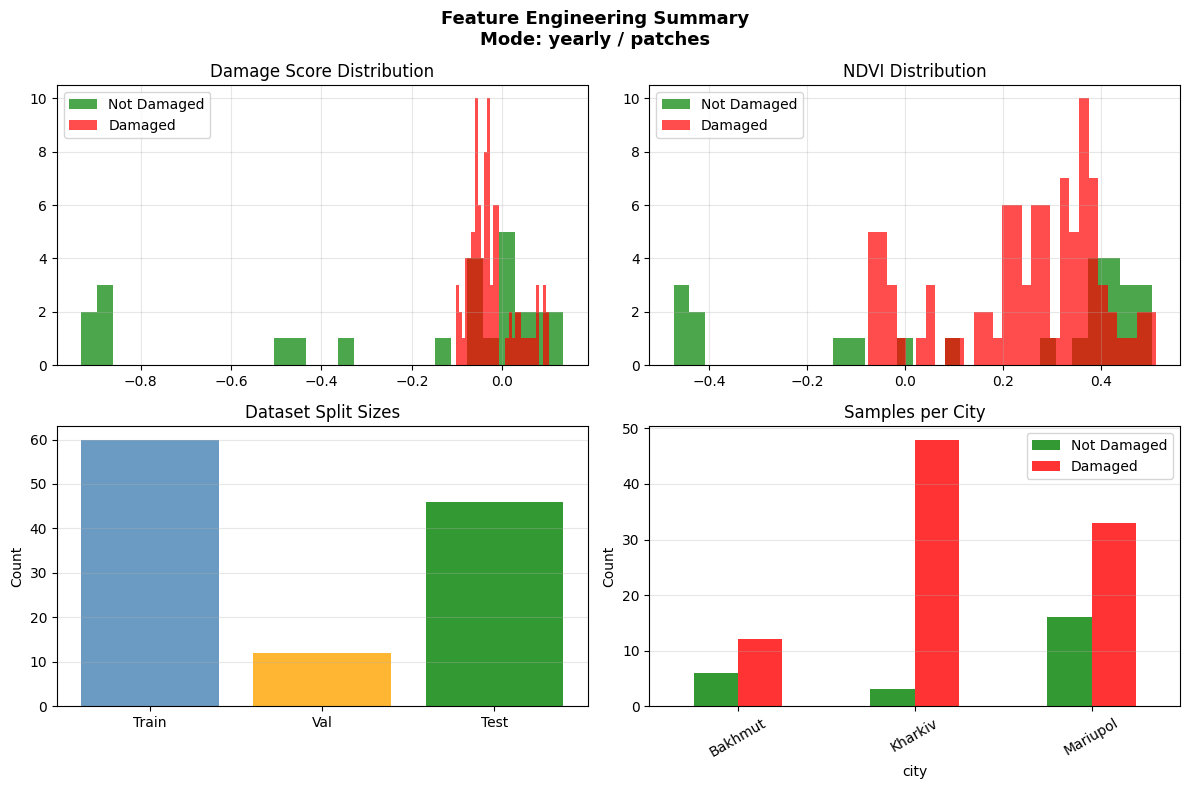

✓ Plot saved to ../results/plots/feature_engineering_yearly_patches.png


In [75]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(
    f'Feature Engineering Summary\n'
    f'Mode: {TEMPORAL_RESOLUTION} / {"patches" if USE_PATCHES else "scene-level"}',
    fontsize=13, fontweight='bold'
)

# 1. Damage score distribution
score_col = 'damage_score'
if score_col in df_dataset.columns:
    axes[0, 0].hist(df_dataset[df_dataset['damage_label']==0][score_col],
                    bins=30, alpha=0.7, label='Not Damaged', color='green')
    axes[0, 0].hist(df_dataset[df_dataset['damage_label']==1][score_col],
                    bins=30, alpha=0.7, label='Damaged', color='red')
    axes[0, 0].set_title('Damage Score Distribution')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

# 2. NDVI distribution
ndvi_col = 'ndvi_mean'
if ndvi_col in df_dataset.columns:
    axes[0, 1].hist(df_dataset[df_dataset['damage_label']==0][ndvi_col],
                    bins=30, alpha=0.7, label='Not Damaged', color='green')
    axes[0, 1].hist(df_dataset[df_dataset['damage_label']==1][ndvi_col],
                    bins=30, alpha=0.7, label='Damaged', color='red')
    axes[0, 1].set_title('NDVI Distribution')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

# 3. Split sizes
axes[1, 0].bar(['Train', 'Val', 'Test'],
               [len(df_train), len(df_val), len(df_test)],
               color=['steelblue', 'orange', 'green'], alpha=0.8)
axes[1, 0].set_title('Dataset Split Sizes')
axes[1, 0].set_ylabel('Count')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Samples per city
city_counts = df_dataset.groupby(['city', 'damage_label']).size().unstack(fill_value=0)
city_counts.plot(kind='bar', ax=axes[1, 1], color=['green', 'red'], alpha=0.8)
axes[1, 1].set_title('Samples per City')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(['Not Damaged', 'Damaged'])
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plot_name = f'feature_engineering_{TEMPORAL_RESOLUTION}_{"patches" if USE_PATCHES else "scenes"}.png'
plt.savefig(f'../results/plots/{plot_name}', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Plot saved to ../results/plots/{plot_name}')

## 8. Summary

In [76]:
print('=' * 70)
print('FEATURE ENGINEERING COMPLETE')
print('=' * 70)
print(f'  Temporal resolution : {TEMPORAL_RESOLUTION}')
print(f'  Patch mode          : {USE_PATCHES}')
if USE_PATCHES:
    print(f'  Patch size          : {PATCH_SIZE}x{PATCH_SIZE}, stride={PATCH_STRIDE}')
print()
print(f'  Total samples  : {len(df_dataset):,}')
print(f'  Train          : {len(df_train):,}')
print(f'  Val            : {len(df_val):,}')
print(f'  Test           : {len(df_test):,}')
print(f'  Feature columns: {df_dataset.shape[1]}')
print()
print('Files saved:')
print('  ../data/splits/train_metadata.csv')
print('  ../data/splits/val_metadata.csv')
print('  ../data/splits/test_metadata.csv')
print('  ../data/processed/patches_metadata.csv')
if USE_PATCHES:
    print('  ../data/patches/patch_*.npy')
print()
print('Next steps:')
print('  → Run Notebook 2b to enrich with GLCM/texture features (optional)')
print('  → Run Notebook 3 for model training')

FEATURE ENGINEERING COMPLETE
  Temporal resolution : yearly
  Patch mode          : True
  Patch size          : 256x256, stride=256

  Total samples  : 118
  Train          : 60
  Val            : 12
  Test           : 46
  Feature columns: 15

Files saved:
  ../data/splits/train_metadata.csv
  ../data/splits/val_metadata.csv
  ../data/splits/test_metadata.csv
  ../data/processed/patches_metadata.csv
  ../data/patches/patch_*.npy

Next steps:
  → Run Notebook 2b to enrich with GLCM/texture features (optional)
  → Run Notebook 3 for model training



---



# Satellite Damage Assessment: Rich Feature Extraction

## Notebook 2b - Scene-Level Feature Enrichment

This notebook sits between Notebook 2 and Notebook 3. It:
1. Loads the existing train/val/test split CSVs from Notebook 2
2. Goes back to the raw `.npy` scene files to extract richer features
3. Adds texture (GLCM), spatial variance, band statistics, and change proxies
4. Overwrites the split CSVs so Notebook 3 automatically benefits

No patches are used — everything stays at scene level.

## 1. Setup & Load Splits

In [77]:
# scikit-image is already installed by the Environment Setup cell at the top.
# Uncomment the line below only if you skipped that cell:
%pip install -q scikit-image


Note: you may need to restart the kernel to use updated packages.


In [78]:
# (scikit-image already installed by the Environment Setup cell)


In [ ]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops
from scipy import stats

print("="*70)
print("RICH FEATURE EXTRACTION")
print("="*70)

# ── Load existing splits ─────────────────────────────────────────────────
df_train = pd.read_csv('../data/splits/train_metadata.csv')
df_val   = pd.read_csv('../data/splits/val_metadata.csv')
df_test  = pd.read_csv('../data/splits/test_metadata.csv')

print(f"\nLoaded splits:")
print(f"  Train: {len(df_train)} scenes")
print(f"  Val:   {len(df_val)} scenes")
print(f"  Test:  {len(df_test)} scenes")
print(f"\nExisting columns ({df_train.shape[1]}):")
print(df_train.columns.tolist())
print(f"\nSample row:")
print(df_train.iloc[0])

PATCH_MODE_DETECTED = 'patch_row' in df_train.columns


RICH FEATURE EXTRACTION

Loaded splits:
  Train: 60 scenes
  Val:   12 scenes
  Test:  46 scenes

Existing columns (15):
['patch_id', 'city', 'period', 'year', 'damage_label', 'patch_row', 'patch_col', 'temporal_res', 'ndvi_mean', 'ndvi_std', 'ndbi_mean', 'ndbi_std', 'bsi_mean', 'bsi_std', 'damage_score']

Sample row:
patch_id                 18
city                Kharkiv
period          2021_annual
year                   2021
damage_label              0
patch_row                 0
patch_col                 0
temporal_res         yearly
ndvi_mean          0.396897
ndvi_std           0.261333
ndbi_mean          0.001132
ndbi_std           0.168704
bsi_mean           0.029962
bsi_std            0.155268
damage_score       0.000682
Name: 0, dtype: object


RuntimeError: ⚠ Notebook 2b detected PATCH MODE splits.
  2b enriches at SCENE level and requires USE_PATCHES=False in Notebook 2.
  Steps:
    1. Set USE_PATCHES=False in Notebook 2 and re-run it
    2. Run Notebook 2b
    3. Set USE_PATCHES=True in Notebook 2 and re-run if you want patches
       (Note: 2b enrichment won't carry over to patch mode)

## 2. Define Feature Extraction Functions

In [ ]:
if PATCH_MODE_DETECTED:
    print("\n⚠ Detected patch mode — rich features extracted at scene level won't carry over to patches.")
    print("  To enrich patch-level data, set USE_PATCHES=False in Notebook 2 and re-run it with this notebook.")
else: 

    # ── Spectral index helpers ────────────────────────────────────────────────
    def compute_ndvi(image):
        red = image[..., 2].astype(float)
        nir = image[..., 3].astype(float)
        return (nir - red) / (nir + red + 1e-8)

    def compute_ndbi(image):
        swir = image[..., 4].astype(float)
        nir  = image[..., 3].astype(float)
        return (swir - nir) / (swir + nir + 1e-8)

    def compute_bsi(image):
        blue = image[..., 0].astype(float)
        red  = image[..., 2].astype(float)
        nir  = image[..., 3].astype(float)
        swir = image[..., 4].astype(float)
        return (swir + red - nir - blue) / (swir + red + nir + blue + 1e-8)


    # ── GLCM texture features ────────────────────────────────────────────────
    def compute_glcm_features(band, levels=64):
        """
        Compute GLCM texture statistics on a 2D band.
        Quantises to `levels` grey levels first for speed.
        Returns contrast, dissimilarity, homogeneity, energy, correlation, ASM.
        """
        # Replace NaNs and quantise to uint8 range 0..levels-1
        band_clean = np.nan_to_num(band, nan=0.0)
        band_min, band_max = band_clean.min(), band_clean.max()
        if band_max - band_min < 1e-8:
            # Uniform image — all texture stats are trivial
            return {
                'glcm_contrast':     0.0,
                'glcm_dissimilarity': 0.0,
                'glcm_homogeneity':  1.0,
                'glcm_energy':       1.0,
                'glcm_correlation':  1.0,
                'glcm_asm':          1.0,
            }

        quantised = ((band_clean - band_min) / (band_max - band_min) * (levels - 1)).astype(np.uint8)

        # Subsample large images to keep runtime reasonable
        if quantised.shape[0] > 256 or quantised.shape[1] > 256:
            step = max(quantised.shape[0] // 256, quantised.shape[1] // 256, 1)
            quantised = quantised[::step, ::step]

        # GLCM over 4 directions, distance=1
        glcm = graycomatrix(quantised, distances=[1],
                            angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                            levels=levels, symmetric=True, normed=True)

        return {
            'glcm_contrast':      float(graycoprops(glcm, 'contrast').mean()),
            'glcm_dissimilarity': float(graycoprops(glcm, 'dissimilarity').mean()),
            'glcm_homogeneity':   float(graycoprops(glcm, 'homogeneity').mean()),
            'glcm_energy':        float(graycoprops(glcm, 'energy').mean()),
            'glcm_correlation':   float(graycoprops(glcm, 'correlation').mean()),
            'glcm_asm':           float(graycoprops(glcm, 'ASM').mean()),
        }


    # ── Quadrant spatial variance ────────────────────────────────────────────
    def compute_quadrant_variance(index_map):
        """
        Split the scene into 4 quadrants and compute the std of each.
        Returns mean and std of the four quadrant stds — captures how
        unevenly damage is distributed across the scene.
        """
        h, w = index_map.shape
        mh, mw = h // 2, w // 2
        quadrants = [
            index_map[:mh, :mw],
            index_map[:mh, mw:],
            index_map[mh:, :mw],
            index_map[mh:, mw:],
        ]
        q_stds = [np.nanstd(q) for q in quadrants]
        return {
            'quadrant_std_mean': float(np.mean(q_stds)),
            'quadrant_std_std':  float(np.std(q_stds)),
        }


    # ── Robust distribution features ─────────────────────────────────────────
    def compute_robust_stats(arr, prefix):
        """
        IQR, skewness, kurtosis, and percentile range of a flattened index map.
        More robust to outlier pixels than min/max.
        """
        flat = arr[np.isfinite(arr)]
        if len(flat) == 0:
            return {f'{prefix}_iqr': 0.0, f'{prefix}_skew': 0.0,
                    f'{prefix}_kurt': 0.0, f'{prefix}_p10': 0.0, f'{prefix}_p90': 0.0}
        return {
            f'{prefix}_iqr':  float(np.percentile(flat, 75) - np.percentile(flat, 25)),
            f'{prefix}_skew': float(stats.skew(flat)),
            f'{prefix}_kurt': float(stats.kurtosis(flat)),
            f'{prefix}_p10':  float(np.percentile(flat, 10)),
            f'{prefix}_p90':  float(np.percentile(flat, 90)),
        }


    # ── Raw band statistics ───────────────────────────────────────────────────
    def compute_band_stats(image):
        """
        Mean and std of the four most informative Sentinel-2 bands:
        RED (B04), NIR (B08), SWIR1 (B11), SWIR2 (B12).
        """
        band_map = {'red': 2, 'nir': 3, 'swir1': 4, 'swir2': 5}
        feats = {}
        for name, idx in band_map.items():
            b = image[..., idx].astype(float)
            b = b[np.isfinite(b)]
            feats[f'band_{name}_mean'] = float(np.nanmean(b)) if len(b) else 0.0
            feats[f'band_{name}_std']  = float(np.nanstd(b))  if len(b) else 0.0
        return feats


    # ── Master function ───────────────────────────────────────────────────────
    def extract_rich_features(filepath):
        """
        Load a cleaned .npy scene and return a dict of all new features.
        Returns None if the file cannot be loaded.
        """
        if not os.path.exists(filepath):
            return None

        image = np.load(filepath)

        ndvi = compute_ndvi(image)
        ndbi = compute_ndbi(image)
        bsi  = compute_bsi(image)
        nir_band = image[..., 3].astype(float)

        feats = {}

        # 1. GLCM texture on NIR band (most sensitive to surface change)
        feats.update(compute_glcm_features(nir_band))

        # 2. Quadrant spatial variance for each index
        for name, arr in [('ndvi', ndvi), ('ndbi', ndbi), ('bsi', bsi)]:
            qv = compute_quadrant_variance(arr)
            feats[f'{name}_quad_std_mean'] = qv['quadrant_std_mean']
            feats[f'{name}_quad_std_std']  = qv['quadrant_std_std']

        # 3. Robust distribution stats for each index
        feats.update(compute_robust_stats(ndvi, 'ndvi'))
        feats.update(compute_robust_stats(ndbi, 'ndbi'))
        feats.update(compute_robust_stats(bsi,  'bsi'))

        # 4. Raw band statistics
        feats.update(compute_band_stats(image))

        # 5. Damage score  (already in nb2 but added here as an explicit feature)
        ndvi_mean = np.nanmean(ndvi)
        ndbi_mean = np.nanmean(ndbi)
        feats['damage_score']         = float((1 - ndvi_mean) * ndbi_mean)
        feats['ndvi_ndbi_ratio']      = float(ndvi_mean / (ndbi_mean + 1e-8))
        feats['vegetation_loss_proxy'] = float(max(0.0, 0.5 - ndvi_mean))  # how far below healthy NDVI

        return feats


    print("✓ All feature extraction functions defined")
    print(f"\nFeatures that will be added per scene:")
    print("  GLCM texture (NIR):     6  features  [contrast, dissimilarity, homogeneity, energy, correlation, ASM]")
    print("  Quadrant variance:      6  features  [ndvi/ndbi/bsi × quad_std_mean/std]")
    print("  Robust index stats:     15 features  [ndvi/ndbi/bsi × iqr/skew/kurt/p10/p90]")
    print("  Raw band stats:         8  features  [red/nir/swir1/swir2 × mean/std]")
    print("  Damage composites:      3  features  [damage_score, ndvi_ndbi_ratio, vegetation_loss_proxy]")
    print("  ─────────────────────────────────────────")
    print("  Total new features:     38")

✓ All feature extraction functions defined

Features that will be added per scene:
  GLCM texture (NIR):     6  features  [contrast, dissimilarity, homogeneity, energy, correlation, ASM]
  Quadrant variance:      6  features  [ndvi/ndbi/bsi × quad_std_mean/std]
  Robust index stats:     15 features  [ndvi/ndbi/bsi × iqr/skew/kurt/p10/p90]
  Raw band stats:         8  features  [red/nir/swir1/swir2 × mean/std]
  Damage composites:      3  features  [damage_score, ndvi_ndbi_ratio, vegetation_loss_proxy]
  ─────────────────────────────────────────
  Total new features:     38


## 3. Resolve Scene File Paths

In [ ]:
if PATCH_MODE_DETECTED:
    print("\n⚠ Detected patch mode — rich features extracted at scene level won't carry over to patches.")
    print("  To enrich patch-level data, set USE_PATCHES=False in Notebook 2 and re-run it with this notebook.")
else: 
    import glob

    print("=" * 70)
    print("Resolving .npy file paths for each scene")
    print("=" * 70)

    df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
    df_all['_split'] = (
        ['train'] * len(df_train) +
        ['val']   * len(df_val)   +
        ['test']  * len(df_test)
    )

    # Use an existing path column if notebook 2 already recorded one
    if 'cleaned_filename' in df_all.columns:
        df_all['_scene_path'] = df_all['cleaned_filename']
        print("Using 'cleaned_filename' column from splits.")
    elif 'filename' in df_all.columns:
        df_all['_scene_path'] = df_all['filename']
        print("Using 'filename' column from splits.")
    else:
        # Scan ../data/raw/ once and build a (city, period) → path lookup.
        # Handles any naming variant without calling os.path.exists() per row.
        known_cities = df_all['city'].unique().tolist()
        scene_lookup = {}

        for path in glob.glob('../data/raw/S2_*_clean.npy'):
            fname = os.path.basename(path)   # e.g. S2_2021_Q1_Mariupol_clean.npy
            stem  = fname[3:-10]             # strip 'S2_' prefix and '_clean.npy' suffix
            for city_name in known_cities:
                if stem.endswith(f'_{city_name}'):
                    period_name = stem[:-(len(city_name) + 1)]
                    scene_lookup[(city_name, period_name)] = path
                    break

        df_all['_scene_path'] = df_all.apply(
            lambda r: scene_lookup.get((r['city'], r['period'])), axis=1
        )
        print(f"Scanned ../data/raw/ — found {len(scene_lookup)} scene files.")

    found   = df_all['_scene_path'].notna().sum()
    missing = df_all['_scene_path'].isna().sum()
    print(f"\n  Scenes found  : {found}")
    print(f"  Scenes missing: {missing}")

    if missing > 0:
        missing_scenes = (
            df_all[df_all['_scene_path'].isna()][['city', 'period']]
            .drop_duplicates()
        )
        print(f"\n  {len(missing_scenes)} unique (city, period) combos not found:")
        print(missing_scenes.to_string(index=False))
        if not glob.glob('../data/raw/S2_*_clean.npy'):
            print("\n  No scene files found at all in ../data/raw/")
            print("  → Run Notebook 1 fully before running this notebook.")
        else:
            print("\n  Some scenes missing — check period/city values match Notebook 1 output.")

Resolving .npy file paths for each scene
Using 'filename' column from splits.

  Scenes found  : 12
  Scenes missing: 0


## 4. Extract Rich Features for All Scenes

In [ ]:
if PATCH_MODE_DETECTED:
    print("\n⚠ Detected patch mode — rich features extracted at scene level won't carry over to patches.")
    print("  To enrich patch-level data, set USE_PATCHES=False in Notebook 2 and re-run it with this notebook.")
else: 
    print("="*70)
    print("Extracting rich features (this may take a few minutes)...")
    print("="*70)

    rich_records = []
    success_count = 0
    skip_count    = 0

    # Deduplicate: each unique scene only needs to be processed once
    # (patches from nb2 create multiple rows per scene — but here we work at scene level)
    unique_scenes = df_all[['city', 'period', '_scene_path']].drop_duplicates(
        subset=['city', 'period']
    ).reset_index(drop=True)

    print(f"\nUnique scenes to process: {len(unique_scenes)}\n")

    scene_feature_cache = {}  # city+period → feature dict

    for _, scene_row in unique_scenes.iterrows():
        key      = (scene_row['city'], scene_row['period'])
        filepath = scene_row['_scene_path']

        if pd.isna(filepath) or filepath is None:
            print(f"  ⚠ SKIP  {scene_row['city']:10} {scene_row['period']} — no file")
            scene_feature_cache[key] = None
            skip_count += 1
            continue

        try:
            feats = extract_rich_features(filepath)
            if feats is None:
                print(f"  ⚠ SKIP  {scene_row['city']:10} {scene_row['period']} — file not found")
                scene_feature_cache[key] = None
                skip_count += 1
            else:
                scene_feature_cache[key] = feats
                success_count += 1
                print(f"  ✓ OK    {scene_row['city']:10} {scene_row['period']}")
        except Exception as e:
            print(f"  ✗ ERROR {scene_row['city']:10} {scene_row['period']} — {str(e)[:60]}")
            scene_feature_cache[key] = None
            skip_count += 1

    print(f"\n{'─'*50}")
    print(f"Processed: {success_count} scenes  |  Skipped: {skip_count} scenes")

Extracting rich features (this may take a few minutes)...

Unique scenes to process: 12

  ✓ OK    Bakhmut    2022_annual
  ✓ OK    Bakhmut    2024_annual
  ✓ OK    Kharkiv    2021_annual
  ✓ OK    Kharkiv    2022_annual
  ✓ OK    Kharkiv    2024_annual
  ✓ OK    Mariupol   2024_annual
  ✓ OK    Bakhmut    2023_annual
  ✓ OK    Kharkiv    2023_annual
  ✓ OK    Bakhmut    2021_annual
  ✓ OK    Mariupol   2021_annual
  ✓ OK    Mariupol   2022_annual
  ✓ OK    Mariupol   2023_annual

──────────────────────────────────────────────────
Processed: 12 scenes  |  Skipped: 0 scenes


## 5. Merge Features Back into Splits

In [ ]:
if PATCH_MODE_DETECTED:
    print("\n⚠ Detected patch mode — rich features extracted at scene level won't carry over to patches.")
    print("  To enrich patch-level data, set USE_PATCHES=False in Notebook 2 and re-run it with this notebook.")
else:
    print("="*70)
    print("Merging features into split DataFrames")
    print("="*70)

    def enrich_split(df):
        """
        For each row in a split DataFrame, look up the pre-computed
        rich features by (city, period) and append them as new columns.
        """
        new_cols = []
        for _, row in df.iterrows():
            key   = (row['city'], row['period'])
            feats = scene_feature_cache.get(key)
            new_cols.append(feats if feats else {})

        feat_df   = pd.DataFrame(new_cols, index=df.index)
        df_merged = pd.concat([df.reset_index(drop=True),
                            feat_df.reset_index(drop=True)], axis=1)
        return df_merged


    df_train_rich = enrich_split(df_train)
    df_val_rich   = enrich_split(df_val)
    df_test_rich  = enrich_split(df_test)

    # Count new columns added
    new_col_count = df_train_rich.shape[1] - df_train.shape[1]
    new_col_names = [c for c in df_train_rich.columns if c not in df_train.columns]

    print(f"\nColumns before enrichment: {df_train.shape[1]}")
    print(f"Columns after enrichment:  {df_train_rich.shape[1]}")
    print(f"New features added:        {new_col_count}")
    print(f"\nNew feature names:")
    for i, col in enumerate(new_col_names, 1):
        print(f"  {i:2d}. {col}")

    # Check for NaN rows (scenes that couldn't be processed)
    nan_rows = df_train_rich[new_col_names].isna().all(axis=1).sum()
    print(f"\nRows with all-NaN new features (train): {nan_rows}")
    if nan_rows > 0:
        print("  These rows had missing .npy files — they will still train on original features.")

Merging features into split DataFrames

Columns before enrichment: 27
Columns after enrichment:  65
New features added:        38

New feature names:
   1. glcm_contrast
   2. glcm_dissimilarity
   3. glcm_homogeneity
   4. glcm_energy
   5. glcm_correlation
   6. glcm_asm
   7. ndvi_quad_std_mean
   8. ndvi_quad_std_std
   9. ndbi_quad_std_mean
  10. ndbi_quad_std_std
  11. bsi_quad_std_mean
  12. bsi_quad_std_std
  13. ndvi_iqr
  14. ndvi_skew
  15. ndvi_kurt
  16. ndvi_p10
  17. ndvi_p90
  18. ndbi_iqr
  19. ndbi_skew
  20. ndbi_kurt
  21. ndbi_p10
  22. ndbi_p90
  23. bsi_iqr
  24. bsi_skew
  25. bsi_kurt
  26. bsi_p10
  27. bsi_p90
  28. band_red_mean
  29. band_red_std
  30. band_nir_mean
  31. band_nir_std
  32. band_swir1_mean
  33. band_swir1_std
  34. band_swir2_mean
  35. band_swir2_std
  36. ndvi_ndbi_ratio
  37. vegetation_loss_proxy

Rows with all-NaN new features (train): 0


## 6. Feature Quality Check

In [ ]:
if PATCH_MODE_DETECTED:
    print("\n⚠ Detected patch mode — rich features are currently extracted at scene level only.")
    print("  All patches from the same scene will have identical rich features.")
    print("  → Run Notebook 2b with USE_PATCHES=False to get scene-level enrichment, then re-run with patches if desired.")
else:
    print("="*70)
    print("Feature Quality Check")
    print("="*70)

    df_all_rich = pd.concat([df_train_rich, df_val_rich, df_test_rich], ignore_index=True)

    print(f"\nNew feature statistics (full dataset):")
    print(df_all_rich[new_col_names].describe().round(4).to_string())

    # Check for any constant columns (no variance = useless for ML)
    constant_cols = [c for c in new_col_names
                    if df_all_rich[c].dropna().std() < 1e-8]
    if constant_cols:
        print(f"\n⚠ Constant columns (will be dropped): {constant_cols}")
        df_train_rich.drop(columns=constant_cols, inplace=True)
        df_val_rich.drop(columns=constant_cols,   inplace=True)
        df_test_rich.drop(columns=constant_cols,  inplace=True)
        new_col_names = [c for c in new_col_names if c not in constant_cols]
        print(f"  Dropped {len(constant_cols)} constant columns.")
    else:
        print(f"\n✓ No constant columns — all {len(new_col_names)} features have variance.")

    # NaN summary
    nan_summary = df_all_rich[new_col_names].isna().sum()
    if nan_summary.sum() > 0:
        print(f"\nNaN counts per feature:")
        print(nan_summary[nan_summary > 0])
        print("\nFilling NaNs with column median...")
        for col in new_col_names:
            med = df_train_rich[col].median()
            df_train_rich[col].fillna(med, inplace=True)
            df_val_rich[col].fillna(med,   inplace=True)
            df_test_rich[col].fillna(med,  inplace=True)
        print("✓ NaNs filled.")
    else:
        print("✓ No NaN values in new features.")

Feature Quality Check

New feature statistics (full dataset):
       glcm_contrast  glcm_dissimilarity  glcm_homogeneity  glcm_energy  glcm_correlation  glcm_asm  ndvi_quad_std_mean  ndvi_quad_std_std  ndbi_quad_std_mean  ndbi_quad_std_std  bsi_quad_std_mean  bsi_quad_std_std  ndvi_iqr  ndvi_skew  ndvi_kurt  ndvi_p10  ndvi_p90  ndbi_iqr  ndbi_skew  ndbi_kurt  ndbi_p10  ndbi_p90  bsi_iqr  bsi_skew  bsi_kurt  bsi_p10  bsi_p90  band_red_mean  band_red_std  band_nir_mean  band_nir_std  band_swir1_mean  band_swir1_std  band_swir2_mean  band_swir2_std  ndvi_ndbi_ratio  vegetation_loss_proxy
count        12.0000             12.0000           12.0000      12.0000           12.0000   12.0000              7.0000             7.0000              7.0000             7.0000             7.0000            7.0000   12.0000    12.0000    12.0000   12.0000   12.0000   12.0000    12.0000    12.0000   12.0000   12.0000  12.0000   12.0000   12.0000  12.0000  12.0000        12.0000       12.0000        12.000

## 7. Feature Importance Preview

Feature Importance Preview (Random Forest, all features)
Feature columns selected for RF preview: 56

Top 20 features by importance:
        feature  importance
       ndvi_p10    0.093750
       bsi_skew    0.078125
        bsi_iqr    0.062500
      ndvi_mean    0.046875
        bsi_p10    0.046875
        bsi_std    0.046875
 scene_ndvi_std    0.046875
       ndvi_min    0.031250
       bsi_kurt    0.031250
      ndbi_kurt    0.031250
       ndbi_iqr    0.031250
       ndbi_p90    0.031250
band_swir2_mean    0.031250
        bsi_p90    0.031250
  band_red_mean    0.031250
ndvi_ndbi_ratio    0.031250
 scene_bsi_mean    0.031250
 scene_ndbi_std    0.031250
  scene_bsi_std    0.015625
        bsi_min    0.015625


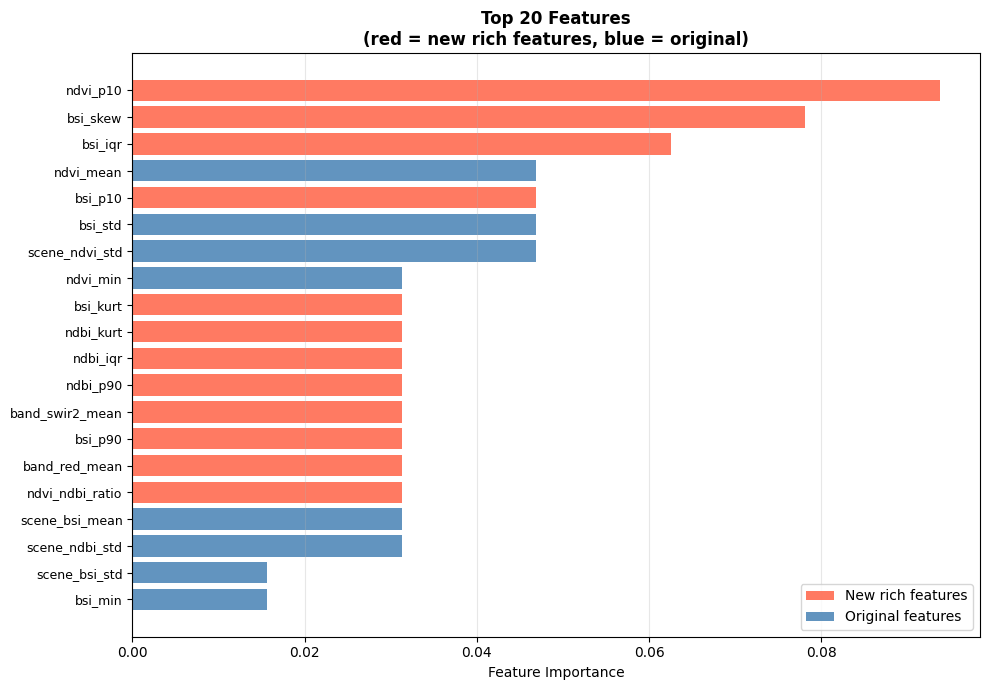


✓ Saved ../results/plots/rich_feature_importance.png


In [ ]:
if PATCH_MODE_DETECTED:
    print("\n⚠ NOTE: Patch mode detected — rich features are currently at scene level and duplicated across patches.")
    print("  Consider setting USE_PATCHES=False in Notebook 2 to avoid confusion, or be aware that these features")
    print("  will not capture patch-level variation and may have limited importance for patch-based models.")
else:
    print("="*70)
    print("Feature Importance Preview (Random Forest, all features)")
    print("="*70)

    from sklearn.ensemble import RandomForestClassifier

    # Derive feature columns directly from the enriched DataFrame:
    # use all numeric columns except metadata and the label.
    exclude = {'damage_label', 'patch_id', 'city', 'period', 'year', 'quarter',
            'filename', 'cleaned_filename', '_scene_path', '_split',
            'cloud_cover_pct', 'valid_pixels_pct', 'scene_id', 'damage_score'}
    all_feature_cols = [
        c for c in df_train_rich.columns
        if c not in exclude
        and pd.api.types.is_numeric_dtype(df_train_rich[c])
        and c != 'damage_label'
    ]

    print(f"Feature columns selected for RF preview: {len(all_feature_cols)}")

    X = df_train_rich[all_feature_cols].fillna(0).values
    y = df_train_rich['damage_label'].values

    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X, y)

    importance_df = pd.DataFrame({
        'feature':    all_feature_cols,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"\nTop 20 features by importance:")
    print(importance_df.head(20).to_string(index=False))

    # Visualise
    top20 = importance_df.head(20)
    colors = ['tomato' if c in new_col_names else 'steelblue'
            for c in top20['feature']]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(range(len(top20)), top20['importance'].values, color=colors, alpha=0.85)
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(top20['feature'].values, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance')
    ax.set_title('Top 20 Features\n(red = new rich features, blue = original)', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='tomato',    alpha=0.85, label='New rich features'),
                    Patch(facecolor='steelblue', alpha=0.85, label='Original features')]
    ax.legend(handles=legend_elements, loc='lower right')

    plt.tight_layout()
    plt.savefig('../results/plots/rich_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✓ Saved ../results/plots/rich_feature_importance.png")

## 8. Damage vs Undamaged Distribution for New Features

Distribution Check: Damaged vs Not Damaged


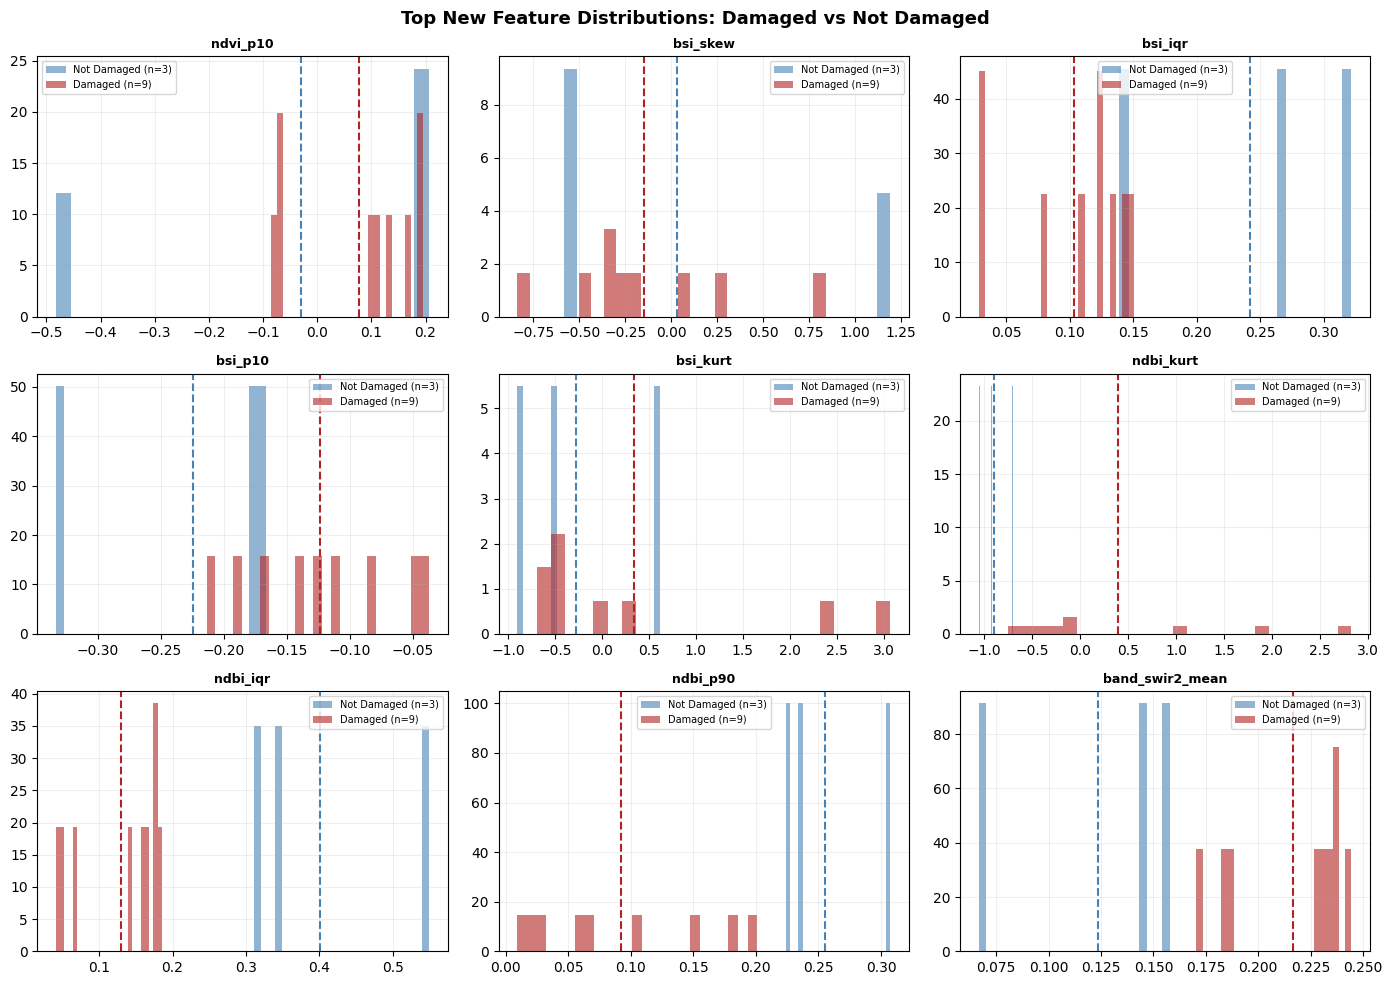


✓ Saved ../results/plots/rich_feature_distributions.png


In [ ]:
if PATCH_MODE_DETECTED:
    print("\n✓ Patch mode detected — skipping distribution check (patch-level features not extracted in this notebook)")
else:
        print("="*70)
        print("Distribution Check: Damaged vs Not Damaged")
        print("="*70)

        # Pick the top 9 new features by importance for the plot
        top_new = [c for c in importance_df['feature'] if c in new_col_names][:9]

        fig, axes = plt.subplots(3, 3, figsize=(14, 10))
        axes = axes.flatten()

        for ax, feat in zip(axes, top_new):
        dam     = df_all_rich[df_all_rich['damage_label'] == 1][feat].dropna()
        not_dam = df_all_rich[df_all_rich['damage_label'] == 0][feat].dropna()

        ax.hist(not_dam, bins=25, alpha=0.6, color='steelblue', density=True,
                label=f'Not Damaged (n={len(not_dam)})')
        ax.hist(dam,     bins=25, alpha=0.6, color='firebrick', density=True,
                label=f'Damaged (n={len(dam)})')
        ax.axvline(not_dam.mean(), color='steelblue', linestyle='--', linewidth=1.5)
        ax.axvline(dam.mean(),     color='firebrick',  linestyle='--', linewidth=1.5)
        ax.set_title(feat, fontsize=9, fontweight='bold')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.2)

        plt.suptitle('Top New Feature Distributions: Damaged vs Not Damaged',
                fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig('../results/plots/rich_feature_distributions.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("\n✓ Saved ../results/plots/rich_feature_distributions.png")

## 9. Save Enriched Splits

In [ ]:
if PATCH_MODE_DETECTED:
    print("\n⚠ NOTE: This notebook enriched SCENE-LEVEL features, but the splits are in PATCH MODE.")
    print("  → To use the new features, set USE_PATCHES=False in Notebook 2 and re-run it.")
    print("  → Then run this notebook again to enrich the new scene-level splits.")
    print("  → Finally, you can switch back to patch mode if desired (but enrichment won't carry over).")
else: 
    print("="*70)
    print("Saving Enriched Split CSVs")
    print("="*70)

    # Back up originals first
    for name in ['train', 'val', 'test']:
        src = f'../data/splits/{name}_metadata.csv'
        dst = f'../data/splits/{name}_metadata_original.csv'
        if os.path.exists(src) and not os.path.exists(dst):
            import shutil
            shutil.copy(src, dst)
            print(f"  Backed up {src} → {dst}")

    # Save enriched versions (overwrites the originals Notebook 3 reads)
    df_train_rich.to_csv('../data/splits/train_metadata.csv', index=False)
    df_val_rich.to_csv('../data/splits/val_metadata.csv',     index=False)
    df_test_rich.to_csv('../data/splits/test_metadata.csv',   index=False)

    print(f"\n✓ Saved ../data/splits/train_metadata.csv  ({df_train_rich.shape[1]} columns)")
    print(f"✓ Saved ../data/splits/val_metadata.csv    ({df_val_rich.shape[1]} columns)")
    print(f"✓ Saved ../data/splits/test_metadata.csv   ({df_test_rich.shape[1]} columns)")

    print(f"\n{'='*70}")
    print("FEATURE ENRICHMENT COMPLETE")
    print("='*70")
    print(f"\n  Original features: {df_train.shape[1]}")
    print(f"  New features added: {new_col_count}")
    print(f"  Total features:     {df_train_rich.shape[1]}")
    print(f"\n  Original backups saved as *_metadata_original.csv")
    print(f"  Enriched CSVs overwrite *_metadata.csv")
    print(f"\n  → Run Notebook 3 as normal — it will automatically use the richer features.")
    print(f"{'='*70}")

Saving Enriched Split CSVs

✓ Saved ../data/splits/train_metadata.csv  (65 columns)
✓ Saved ../data/splits/val_metadata.csv    (65 columns)
✓ Saved ../data/splits/test_metadata.csv   (65 columns)

FEATURE ENRICHMENT COMPLETE
='*70

  Original features: 27
  New features added: 38
  Total features:     65

  Original backups saved as *_metadata_original.csv
  Enriched CSVs overwrite *_metadata.csv

  → Run Notebook 3 as normal — it will automatically use the richer features.



---



# Satellite Damage Assessment: Model Training

## Notebook 3 - Training Damage Classifiers

This notebook automatically detects whether the data came from **patch mode**
or **scene-level mode** (set in Notebook 2) and trains accordingly:

| Mode | Models trained |
|------|----------------|
| **Patch mode** | ResNet-50 (primary) + Logistic Regression + Random Forest + MLP (baselines) |
| **Scene-level mode** | Logistic Regression + Random Forest + MLP |

All results are saved to `../results/metrics/` for Notebook 4.

## 1. Setup & Load Data

In [ ]:
import pandas as pd
import numpy as np
import os
import json
import pickle
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, balanced_accuracy_score
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, WeightedRandomSampler
import torchvision.models as tv_models
import torchvision.transforms.functional as TF

from torchgeo.models import ResNet50_Weights

# Directories
os.makedirs('../models', exist_ok=True)
os.makedirs('../results/metrics', exist_ok=True)
os.makedirs('../results/plots', exist_ok=True)
os.makedirs('../results/predictions', exist_ok=True)

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# Load splits
print('\n' + '='*70)
print('Loading splits from Notebook 2')
print('='*70)

df_train = pd.read_csv('../data/splits/train_metadata.csv')
df_val   = pd.read_csv('../data/splits/val_metadata.csv')
df_test  = pd.read_csv('../data/splits/test_metadata.csv')

print(f'  Train : {len(df_train):,} rows')
print(f'  Val   : {len(df_val):,} rows')
print(f'  Test  : {len(df_test):,} rows')
print(f'  Columns: {df_train.shape[1]}')

# Detect pipeline mode
# Notebook 2 writes a 'temporal_res' column and saves patch .npy files
TEMPORAL_RES = df_train['temporal_res'].iloc[0] if 'temporal_res' in df_train.columns else 'unknown'
PATCH_MODE   = ('patch_id' in df_train.columns and
                os.path.exists('../data/patches/patch_000000.npy'))

print(f'\nDetected mode:')
print(f'  Temporal resolution : {TEMPORAL_RES}')
print(f'  Patch mode          : {PATCH_MODE}')
if PATCH_MODE:
    print('  → Will train ResNet-50 + tabular baselines')
else:
    print('  → Will train tabular baselines only (LR, RF, MLP)')

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/688.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/688.1 kB ? eta -:--:--
   --------------- ------------------------ 262.1/688.1 kB ? eta -:--:--
   --------------- ------------------------ 262.1/688.1 kB ? eta -:--:--
   ---------------------------- --------- 524.3/688.1 kB 419.4 kB/s eta 0:00:01
   ---------------------------- --------- 524.3/688.1 kB 419.4 kB/s eta 0:00:01
   ---------------------------------------- 688.1/688.1 kB 486.8 kB/s  0:00:01
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   --

## 2. Extract Tabular Features & Labels

Used by Logistic Regression, Random Forest, and MLP regardless of mode.

In [ ]:
print('='*70)
print('Extracting Tabular Features & Labels')
print('='*70)

# Feature selection
# Use all numeric columns except metadata and labels.
# Load from saved JSON if it exists (produced by a previous run),
# otherwise derive from the dataframe.
FEATURE_COLS_PATH = '../models/feature_cols.json'
exclude = {
    'patch_id', 'patch_row', 'patch_col',
    'damage_label', 'damage_score',
    'city', 'period', 'year', 'quarter',
    'filename', 'cleaned_filename', '_scene_path', '_split',
    'cloud_cover_pct', 'valid_pixels_pct', 'scene_id', 'temporal_res'
}

feature_cols = [
    c for c in df_train.columns
    if c not in exclude
    and pd.api.types.is_numeric_dtype(df_train[c])
]

print(f'  Selected {len(feature_cols)} feature columns')
print(f'  Features: {feature_cols}')

# Extract arrays
X_train_raw = df_train[feature_cols].values.astype(np.float32)
y_train     = df_train['damage_label'].values.astype(np.int64)

X_val_raw   = df_val[feature_cols].values.astype(np.float32)
y_val       = df_val['damage_label'].values.astype(np.int64)

X_test_raw  = df_test[feature_cols].values.astype(np.float32)
y_test      = df_test['damage_label'].values.astype(np.int64)

# Impute NaNs
nan_count = np.isnan(X_train_raw).sum()
if nan_count > 0:
    print(f'\n  ⚠ {nan_count} NaNs found in training features — imputing with column median')

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_val_imp   = imputer.transform(X_val_raw)
X_test_imp  = imputer.transform(X_test_raw)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled   = scaler.transform(X_val_imp)
X_test_scaled  = scaler.transform(X_test_imp)

print(f'\n  X_train : {X_train_scaled.shape}  |  y_train : {y_train.shape}')
print(f'  X_val   : {X_val_scaled.shape}  |  y_val   : {y_val.shape}')
print(f'  X_test  : {X_test_scaled.shape}  |  y_test  : {y_test.shape}')
print(f'  NaNs remaining: {np.isnan(X_train_scaled).sum()}')

# Persist preprocessing objects
with open('../models/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)
with open('../models/imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('\n✓ feature_cols.json, imputer.pkl, scaler.pkl saved')

Extracting Tabular Features & Labels
  Selected 57 feature columns
  Features: ['ndvi_mean', 'ndvi_std', 'ndvi_min', 'ndvi_max', 'ndbi_mean', 'ndbi_std', 'ndbi_min', 'ndbi_max', 'bsi_mean', 'bsi_std', 'bsi_min', 'bsi_max', 'scene_ndvi_mean', 'scene_ndvi_std', 'scene_ndbi_mean', 'scene_ndbi_std', 'scene_bsi_mean', 'scene_bsi_std', 'scene_damage_score', 'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation', 'glcm_asm', 'ndvi_quad_std_mean', 'ndvi_quad_std_std', 'ndbi_quad_std_mean', 'ndbi_quad_std_std', 'bsi_quad_std_mean', 'bsi_quad_std_std', 'ndvi_iqr', 'ndvi_skew', 'ndvi_kurt', 'ndvi_p10', 'ndvi_p90', 'ndbi_iqr', 'ndbi_skew', 'ndbi_kurt', 'ndbi_p10', 'ndbi_p90', 'bsi_iqr', 'bsi_skew', 'bsi_kurt', 'bsi_p10', 'bsi_p90', 'band_red_mean', 'band_red_std', 'band_nir_mean', 'band_nir_std', 'band_swir1_mean', 'band_swir1_std', 'band_swir2_mean', 'band_swir2_std', 'damage_score.1', 'ndvi_ndbi_ratio', 'vegetation_loss_proxy']

  ⚠ 24 NaNs found in training

## 3. Train Logistic Regression (Baseline)

In [ ]:
print('='*70)
print('Training Logistic Regression')
print('='*70)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_train_pred   = lr_model.predict(X_train_scaled)
y_val_pred     = lr_model.predict(X_val_scaled)
y_test_pred    = lr_model.predict(X_test_scaled)
y_test_proba   = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_results = {
    'model'          : 'Logistic Regression',
    'train_acc'      : accuracy_score(y_train, y_train_pred),
    'val_acc'        : accuracy_score(y_val,   y_val_pred),
    'test_acc'       : accuracy_score(y_test,  y_test_pred),
    'test_precision' : precision_score(y_test, y_test_pred, zero_division=0),
    'test_recall'    : recall_score(y_test,    y_test_pred, zero_division=0),
    'test_f1'        : f1_score(y_test,        y_test_pred, zero_division=0),
    'test_auc'       : roc_auc_score(y_test,   y_test_proba)
}

for k, v in lr_results.items():
    if k != 'model':
        print(f'  {k:20s}: {v:.4f}')

with open('../models/logistic_regression.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print('\n✓ Saved ../models/logistic_regression.pkl')

Training Logistic Regression
  train_acc           : 1.0000
  val_acc             : 1.0000
  test_acc            : 1.0000
  test_precision      : 1.0000
  test_recall         : 1.0000
  test_f1             : 1.0000
  test_auc            : 1.0000

✓ Saved ../models/logistic_regression.pkl


## 4. Train Random Forest (Baseline)

In [ ]:
print('='*70)
print('Training Random Forest')
print('='*70)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

y_train_pred  = rf_model.predict(X_train_scaled)
y_val_pred    = rf_model.predict(X_val_scaled)
y_test_pred   = rf_model.predict(X_test_scaled)
y_test_proba  = rf_model.predict_proba(X_test_scaled)[:, 1]

rf_results = {
    'model'          : 'Random Forest',
    'train_acc'      : accuracy_score(y_train, y_train_pred),
    'val_acc'        : accuracy_score(y_val,   y_val_pred),
    'test_acc'       : accuracy_score(y_test,  y_test_pred),
    'test_precision' : precision_score(y_test, y_test_pred, zero_division=0),
    'test_recall'    : recall_score(y_test,    y_test_pred, zero_division=0),
    'test_f1'        : f1_score(y_test,        y_test_pred, zero_division=0),
    'test_auc'       : roc_auc_score(y_test,   y_test_proba)
}

for k, v in rf_results.items():
    if k != 'model':
        print(f'  {k:20s}: {v:.4f}')

feature_importance = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f'\nTop 10 Features:')
print(feature_importance.head(10).to_string(index=False))

with open('../models/random_forest.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print('\n✓ Saved ../models/random_forest.pkl')

Training Random Forest
  train_acc           : 1.0000
  val_acc             : 1.0000
  test_acc            : 0.5000
  test_precision      : 0.5000
  test_recall         : 1.0000
  test_f1             : 0.6667
  test_auc            : 1.0000

Top 10 Features:
        feature  importance
       ndvi_min    0.093750
      ndvi_mean    0.062500
scene_ndvi_mean    0.062500
 scene_bsi_mean    0.046875
       ndvi_p90    0.046875
ndvi_ndbi_ratio    0.046875
      ndvi_kurt    0.031250
  scene_bsi_std    0.031250
 scene_ndbi_std    0.031250
       ndbi_iqr    0.031250

✓ Saved ../models/random_forest.pkl


## 5. Train MLP (Baseline)

In [ ]:
print('='*70)
print('Training MLP Classifier')
print('='*70)

class TabularMLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(64, 32),         nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 2)
        )
    def forward(self, x):
        return self.net(x)

X_train_t = torch.FloatTensor(X_train_scaled).to(DEVICE)
y_train_t = torch.LongTensor(y_train).to(DEVICE)
X_val_t   = torch.FloatTensor(X_val_scaled).to(DEVICE)
y_val_t   = torch.LongTensor(y_val).to(DEVICE)
X_test_t  = torch.FloatTensor(X_test_scaled).to(DEVICE)

train_loader_tab = DataLoader(
    TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True
)

nn_model  = TabularMLP(input_size=X_train_scaled.shape[1]).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(nn_model.parameters(), lr=1e-3)

MLP_EPOCHS = 50
best_val_loss = float('inf')
mlp_train_losses, mlp_val_losses = [], []

print(f'Training for {MLP_EPOCHS} epochs...')
for epoch in range(MLP_EPOCHS):
    nn_model.train()
    ep_loss = 0.0
    for xb, yb in train_loader_tab:
        optimizer.zero_grad()
        loss = criterion(nn_model(xb), yb)
        loss.backward()
        optimizer.step()
        ep_loss += loss.item()
    ep_loss /= len(train_loader_tab)
    mlp_train_losses.append(ep_loss)

    nn_model.eval()
    with torch.no_grad():
        vl = criterion(nn_model(X_val_t), y_val_t).item()
    mlp_val_losses.append(vl)

    if vl < best_val_loss:
        best_val_loss = vl
        torch.save(nn_model.state_dict(), '../models/mlp_best.pth')

    if (epoch + 1) % 10 == 0:
        print(f'  Epoch {epoch+1:3d}/{MLP_EPOCHS}  train={ep_loss:.4f}  val={vl:.4f}')

# Load best weights and evaluate
nn_model.load_state_dict(torch.load('../models/mlp_best.pth', map_location=DEVICE))
nn_model.eval()
with torch.no_grad():
    y_train_pred  = torch.argmax(nn_model(X_train_t), 1).cpu().numpy()
    y_val_pred    = torch.argmax(nn_model(X_val_t),   1).cpu().numpy()
    test_out      = nn_model(X_test_t)
    y_test_pred   = torch.argmax(test_out, 1).cpu().numpy()
    y_test_proba  = torch.softmax(test_out, 1)[:, 1].cpu().numpy()

nn_results = {
    'model'          : 'MLP',
    'train_acc'      : accuracy_score(y_train, y_train_pred),
    'val_acc'        : accuracy_score(y_val,   y_val_pred),
    'test_acc'       : accuracy_score(y_test,  y_test_pred),
    'test_precision' : precision_score(y_test, y_test_pred, zero_division=0),
    'test_recall'    : recall_score(y_test,    y_test_pred, zero_division=0),
    'test_f1'        : f1_score(y_test,        y_test_pred, zero_division=0),
    'test_auc'       : roc_auc_score(y_test,   y_test_proba)
}

for k, v in nn_results.items():
    if k != 'model':
        print(f'  {k:20s}: {v:.4f}')

# Save final weights (the best already saved above)
torch.save(nn_model.state_dict(), '../models/neural_network.pth')
print('\n✓ Saved ../models/neural_network.pth')

Training MLP Classifier
Training for 50 epochs...
  Epoch  10/50  train=0.5972  val=0.5708
  Epoch  20/50  train=0.5317  val=0.4365
  Epoch  30/50  train=0.4000  val=0.2994
  Epoch  40/50  train=0.2432  val=0.1605
  Epoch  50/50  train=0.1458  val=0.0663
  train_acc           : 1.0000
  val_acc             : 1.0000
  test_acc            : 1.0000
  test_precision      : 1.0000
  test_recall         : 1.0000
  test_f1             : 1.0000
  test_auc            : 1.0000

✓ Saved ../models/neural_network.pth


### Chech Patches

In [ ]:
if not PATCH_MODE:
    print('Scene-level mode detected - skipping ResNet-50.')
    print('Set USE_PATCHES=True in Notebook 2 and re-run to enable ResNet-50.')
else:
    # Check if patches are valid 
    import random

    print("DIAGNOSTIC: Checking patch files...")
    print("=" * 70)

    # Check a random patch
    sample_idx = random.randint(0, len(df_train) - 1)
    sample_row = df_train.iloc[sample_idx]
    sample_patch_id = int(sample_row['patch_id'])
    sample_path = f'../data/patches/patch_{sample_patch_id:06d}.npy'

    print(f"Loading sample patch: {sample_path}")
    sample_patch = np.load(sample_path)

    print(f"  Shape: {sample_patch.shape}")
    print(f"  Dtype: {sample_patch.dtype}")
    print(f"  Min value: {np.nanmin(sample_patch):.2f}")
    print(f"  Max value: {np.nanmax(sample_patch):.2f}")
    print(f"  Mean value: {np.nanmean(sample_patch):.2f}")
    print(f"  Contains NaN: {np.isnan(sample_patch).any()}")
    print(f"  Contains Inf: {np.isinf(sample_patch).any()}")
    print(f"  All zeros: {(sample_patch == 0).all()}")

    print(f"\nChecking all patches...")
    has_nan = 0
    has_inf = 0
    all_zeros = 0

    for i in range(min(100, len(df_train))):
        patch_id = int(df_train.iloc[i]['patch_id'])
        path = f'../data/patches/patch_{patch_id:06d}.npy'
        try:
            p = np.load(path)
            if np.isnan(p).any():
                has_nan += 1
            if np.isinf(p).any():
                has_inf += 1
            if (p == 0).all():
                all_zeros += 1
        except Exception as e:
            print(f"Error loading patch {patch_id}: {e}")

    print(f"  NaN found in {has_nan}/100 patches")
    print(f"  Inf found in {has_inf}/100 patches")
    print(f"  All zeros: {all_zeros}/100 patches")

    if has_nan > 0 or has_inf > 0 or all_zeros > 10:
        print("\n  PROBLEM: Patches are corrupted!")
    else:
        print("\n✓ Patches look OK")

Scene-level mode detected - skipping ResNet-50.
Set USE_PATCHES=True in Notebook 2 and re-run to enable ResNet-50.


## 6. ResNet-50 Training (Patch Mode Only)

This section runs **only when patch `.npy` files are present**.
If you are in scene-level mode it is skipped automatically.

In [97]:
resnet_results = None  # will remain None if patch mode is off
resnet_train_losses, resnet_val_losses = [], []

if not PATCH_MODE:
    print('Scene-level mode detected — skipping ResNet-50.')
    print('Set USE_PATCHES=True in Notebook 2 and re-run to enable ResNet-50.')
else:
    print('='*70)
    print('ResNet-50 Patch Dataset & DataLoader')
    print('='*70)

    # Dataset
    class SentinelPatchDataset(Dataset):
        """
        Loads 128x128 Sentinel-2 patches from .npy files.
        Each patch has shape (H, W, C) — we convert to (C, H, W) for PyTorch.
        We use the first 6 bands (Blue, Green, Red, NIR, SWIR1, SWIR2).
        Pixels are normalised to [0, 1] by dividing by 10000 (Sentinel-2 scale).
        """
        def __init__(self, df, patch_dir='../data/patches', n_bands=6, augment=False):
            self.df        = df.reset_index(drop=True)
            self.patch_dir = patch_dir
            self.n_bands   = n_bands
            self.augment   = augment

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            row      = self.df.iloc[idx]
            patch_id = int(row['patch_id'])
            label    = int(row['damage_label'])

            path  = os.path.join(self.patch_dir, f'patch_{patch_id:06d}.npy')
            patch = np.load(path).astype(np.float32)          # (H, W, C)

            # Keep only the first n_bands
            if patch.ndim == 3 and patch.shape[2] >= self.n_bands:
                patch = patch[:, :, :self.n_bands]
            elif patch.ndim == 3 and patch.shape[2] < self.n_bands:
                # Pad missing bands with zeros
                pad   = np.zeros((*patch.shape[:2], self.n_bands - patch.shape[2]), dtype=np.float32)
                patch = np.concatenate([patch, pad], axis=2)

            # Normalise: Sentinel-2 surface reflectance values are 0–10000
            patch = np.clip(patch / 10000.0, 0.0, 1.0)

            # (H, W, C) → (C, H, W)
            tensor = torch.from_numpy(patch.transpose(2, 0, 1))
            
            # ImageNet normalization for RGB bands (first 3 channels)
            imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            imagenet_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

            # Apply to first 3 bands only (Blue, Green, Red)
            tensor[:3, :, :] = (tensor[:3, :, :] - imagenet_mean) / imagenet_std

            # For NIR, SWIR1, SWIR2 (bands 4-6), use simple [0,1] as-is
            # They don't have ImageNet priors, so [0,1] is reasonable

            # Light augmentation on training patches
            if self.augment:
                if torch.rand(1).item() > 0.5:
                    tensor = TF.hflip(tensor)
                if torch.rand(1).item() > 0.5:
                    tensor = TF.vflip(tensor)

            return tensor, label

    BATCH_SIZE = 32
    N_BANDS    = 6

    # Class weights to handle potential imbalance
    class_counts = np.bincount(y_train)
    # class_weights = torch.FloatTensor(1.0 / class_counts).to(DEVICE)
    # class_weights = class_weights / class_weights.sum()
    weight_for_0 = len(y_train) / (2 * class_counts[0])  # undamaged (minority)
    weight_for_1 = len(y_train) / (2 * class_counts[1])  # damaged (majority)
    class_weights = torch.FloatTensor([weight_for_0, weight_for_1]).to(DEVICE)

    sample_weights = np.where(y_train == 0, weight_for_0, weight_for_1)
    sampler = WeightedRandomSampler(
        weights=torch.FloatTensor(sample_weights),
        num_samples=len(y_train),
        replacement=True
    )

    train_ds = SentinelPatchDataset(df_train, augment=True)
    val_ds   = SentinelPatchDataset(df_val,   augment=False)
    test_ds  = SentinelPatchDataset(df_test,  augment=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                            num_workers=0, pin_memory=(DEVICE.type == 'cuda'))
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=0, pin_memory=(DEVICE.type == 'cuda'))
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=0, pin_memory=(DEVICE.type == 'cuda'))

    print(f'  Train batches : {len(train_loader)}')
    print(f'  Val batches   : {len(val_loader)}')
    print(f'  Test batches  : {len(test_loader)}')

    # Model
    print('\nBuilding ResNet-50...')
    
    resnet = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V2)
    resnet = tv_models.resnet50(weights=None)
    weights = ResNet50_Weights.SENTINEL2_ALL_MOCO
    # Replace first conv layer: 3 RGB channels → N_BANDS Sentinel-2 channels
    # We copy the pretrained RGB weights into the first 3 channels and
    # initialise the extra channels as the mean of those 3 (a sensible prior).
    old_conv   = resnet.conv1
    new_conv   = nn.Conv2d(
        N_BANDS, old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False
    )
    with torch.no_grad():
        new_conv.weight[:, :3, :, :] = old_conv.weight           # copy RGB weights
        for b in range(3, N_BANDS):                               # initialise extra bands
            new_conv.weight[:, b, :, :] = old_conv.weight.mean(dim=1)
    resnet.conv1 = new_conv

    # Replace final fully-connected layer for binary classification
    in_features   = resnet.fc.in_features
    resnet.fc     = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 2)
    )

    resnet = resnet.to(DEVICE)
    total_params     = sum(p.numel() for p in resnet.parameters())
    trainable_params = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
    print(f'  Total params     : {total_params:,}')
    print(f'  Trainable params : {trainable_params:,}')
    print(f'  Input channels   : {N_BANDS}')

    # Training
    RESNET_EPOCHS = 40
    LR_INIT       = 1e-4
    PATIENCE      = 7     # early stopping patience

    resnet_criterion = nn.CrossEntropyLoss(weight=class_weights)
    resnet_optimizer = optim.AdamW(resnet.parameters(), lr=LR_INIT, weight_decay=1e-4)

    # Cosine annealing LR schedule
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        resnet_optimizer, T_max=RESNET_EPOCHS, eta_min=1e-6
    )

    print(f'\nTraining ResNet-50 for up to {RESNET_EPOCHS} epochs '
          f'(early stopping patience={PATIENCE})...')
    print(f'  LR={LR_INIT}, weight_decay=1e-4, cosine annealing')
    print(f'  Class weights: {class_weights.cpu().numpy().round(4)}')
    print()

    best_resnet_val_loss = 0.0  # now tracking best balanced accuracy
    patience_counter     = 0

    for epoch in range(RESNET_EPOCHS):
        # ── Train ──
        resnet.train()
        ep_loss, ep_correct, ep_total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            resnet_optimizer.zero_grad()
            out  = resnet(imgs)
            loss = resnet_criterion(out, labels)
            loss.backward()
            resnet_optimizer.step()
            ep_loss    += loss.item() * imgs.size(0)
            ep_correct += (out.argmax(1) == labels).sum().item()
            ep_total   += imgs.size(0)

        train_loss = ep_loss / ep_total
        train_acc  = ep_correct / ep_total
        resnet_train_losses.append(train_loss)

        # Validate
        vl_loss, vl_correct, vl_total = 0.0, 0, 0
        val_preds_ep = []
        val_labels_ep = []
        resnet.eval()
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out = resnet(imgs)
                val_preds_ep.extend(out.argmax(1).cpu().numpy())
                val_labels_ep.extend(labels.cpu().numpy())
                vl_loss    += resnet_criterion(out, labels).item() * imgs.size(0)
                vl_correct += (out.argmax(1) == labels).sum().item()
                vl_total   += imgs.size(0)

        val_loss     = vl_loss / vl_total
        val_acc      = vl_correct / vl_total
        val_bal_acc  = balanced_accuracy_score(val_labels_ep, val_preds_ep)  # ← use this
        resnet_val_losses.append(val_loss)

        print(f'  Epoch {epoch+1:3d}/{RESNET_EPOCHS}  '
            f'train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  '
            f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  '
            f'val_bal_acc={val_bal_acc:.4f}  lr={scheduler.get_last_lr()[0]:.2e}')

        # Early stopping on balanced accuracy (higher is better)
        if val_bal_acc > best_resnet_val_loss:   # reuse variable, now tracking best bal_acc
            best_resnet_val_loss = val_bal_acc
            patience_counter = 0
            torch.save(resnet.state_dict(), '../models/resnet50_best.pth')
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'  Early stopping at epoch {epoch+1} (patience={PATIENCE})')
                break

    # Evaluate on test set
    print('\nLoading best ResNet-50 checkpoint for test evaluation...')
    if os.path.exists('../models/resnet50_best.pth'):
        resnet.load_state_dict(torch.load('../models/resnet50_best.pth', map_location=DEVICE))
        print('  Loaded best checkpoint.')
    else:
        print('  Warning: no checkpoint found (model never improved val_bal_acc > 0) — using final epoch weights.')
        os.makedirs('../models', exist_ok=True)
        torch.save(resnet.state_dict(), '../models/resnet50_best.pth')
    resnet.eval()

    all_preds, all_proba, all_labels = [], [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(DEVICE)
            out  = resnet(imgs)
            prob = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
            pred = out.argmax(1).cpu().numpy()
            all_preds.append(pred)
            all_proba.append(prob)
            all_labels.append(labels.numpy())

    y_test_pred_resnet  = np.concatenate(all_preds)
    y_test_proba_resnet = np.concatenate(all_proba)
    y_test_labels       = np.concatenate(all_labels)

    # Also get train/val acc for the comparison table
    def eval_loader(loader, model):
        correct, total = 0, 0
        model.eval()
        with torch.no_grad():
            for imgs, labels in loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                correct += (model(imgs).argmax(1) == labels).sum().item()
                total   += imgs.size(0)
        return correct / total

    resnet_results = {
        'model'          : 'ResNet-50',
        'train_acc'      : eval_loader(train_loader, resnet),
        'val_acc'        : eval_loader(val_loader,   resnet),
        'test_acc'       : accuracy_score(y_test_labels,  y_test_pred_resnet),
        'test_precision' : precision_score(y_test_labels, y_test_pred_resnet, zero_division=0),
        'test_recall'    : recall_score(y_test_labels,    y_test_pred_resnet, zero_division=0),
        'test_f1'        : f1_score(y_test_labels,        y_test_pred_resnet, zero_division=0),
        'test_auc'       : roc_auc_score(y_test_labels,   y_test_proba_resnet)
    }

    print('\nResNet-50 Test Results:')
    for k, v in resnet_results.items():
        if k != 'model':
            print(f'  {k:20s}: {v:.4f}')

    print('\n✓ Best weights saved to ../models/resnet50_best.pth')

ResNet-50 Patch Dataset & DataLoader
  Train batches : 2
  Val batches   : 1
  Test batches  : 2

Building ResNet-50...
  Total params     : 23,521,538
  Trainable params : 23,521,538
  Input channels   : 6

Training ResNet-50 for up to 40 epochs (early stopping patience=7)...
  LR=0.0001, weight_decay=1e-4, cosine annealing
  Class weights: [1.5789 0.7317]

  Epoch   1/40  train_loss=0.6991  train_acc=0.4833  val_loss=0.7202  val_acc=0.0000  val_bal_acc=0.0000  lr=1.00e-04
  Epoch   2/40  train_loss=0.8010  train_acc=0.5167  val_loss=0.7462  val_acc=0.0000  val_bal_acc=0.0000  lr=1.00e-04
  Epoch   3/40  train_loss=0.6878  train_acc=0.5333  val_loss=0.8651  val_acc=0.0000  val_bal_acc=0.0000  lr=1.00e-04
  Epoch   4/40  train_loss=0.6305  train_acc=0.5167  val_loss=0.9355  val_acc=0.0000  val_bal_acc=0.0000  lr=1.00e-04
  Epoch   5/40  train_loss=0.7590  train_acc=0.4333  val_loss=1.0025  val_acc=0.0000  val_bal_acc=0.0000  lr=1.00e-04
  Epoch   6/40  train_loss=0.7057  train_acc=0.43

## 7. Model Comparison

In [98]:
print('='*70)
print('MODEL COMPARISON')
print('='*70)

all_results = [lr_results, rf_results, nn_results]
if resnet_results is not None:
    all_results.append(resnet_results)

results_df = pd.DataFrame(all_results)
print(results_df.to_string(index=False))

best_idx        = results_df['test_f1'].idxmax()
best_model_name = results_df.loc[best_idx, 'model']
best_f1         = results_df.loc[best_idx, 'test_f1']

print(f'\nBest model: {best_model_name}  (F1 = {best_f1:.4f})')

results_df.to_csv('../results/metrics/model_comparison.csv', index=False)
print('\n✓ Saved ../results/metrics/model_comparison.csv')

MODEL COMPARISON
              model  train_acc  val_acc  test_acc  test_precision  test_recall  test_f1  test_auc
Logistic Regression   0.966667      1.0  0.956522           0.975        0.975    0.975  0.987500
      Random Forest   1.000000      1.0  0.956522           0.975        0.975    0.975  0.987500
                MLP   0.966667      1.0  0.956522           0.975        0.975    0.975  0.991667
          ResNet-50   0.500000      0.0  0.130435           0.000        0.000    0.000  0.000000

Best model: Logistic Regression  (F1 = 0.9750)

✓ Saved ../results/metrics/model_comparison.csv


## 8. Visualizations

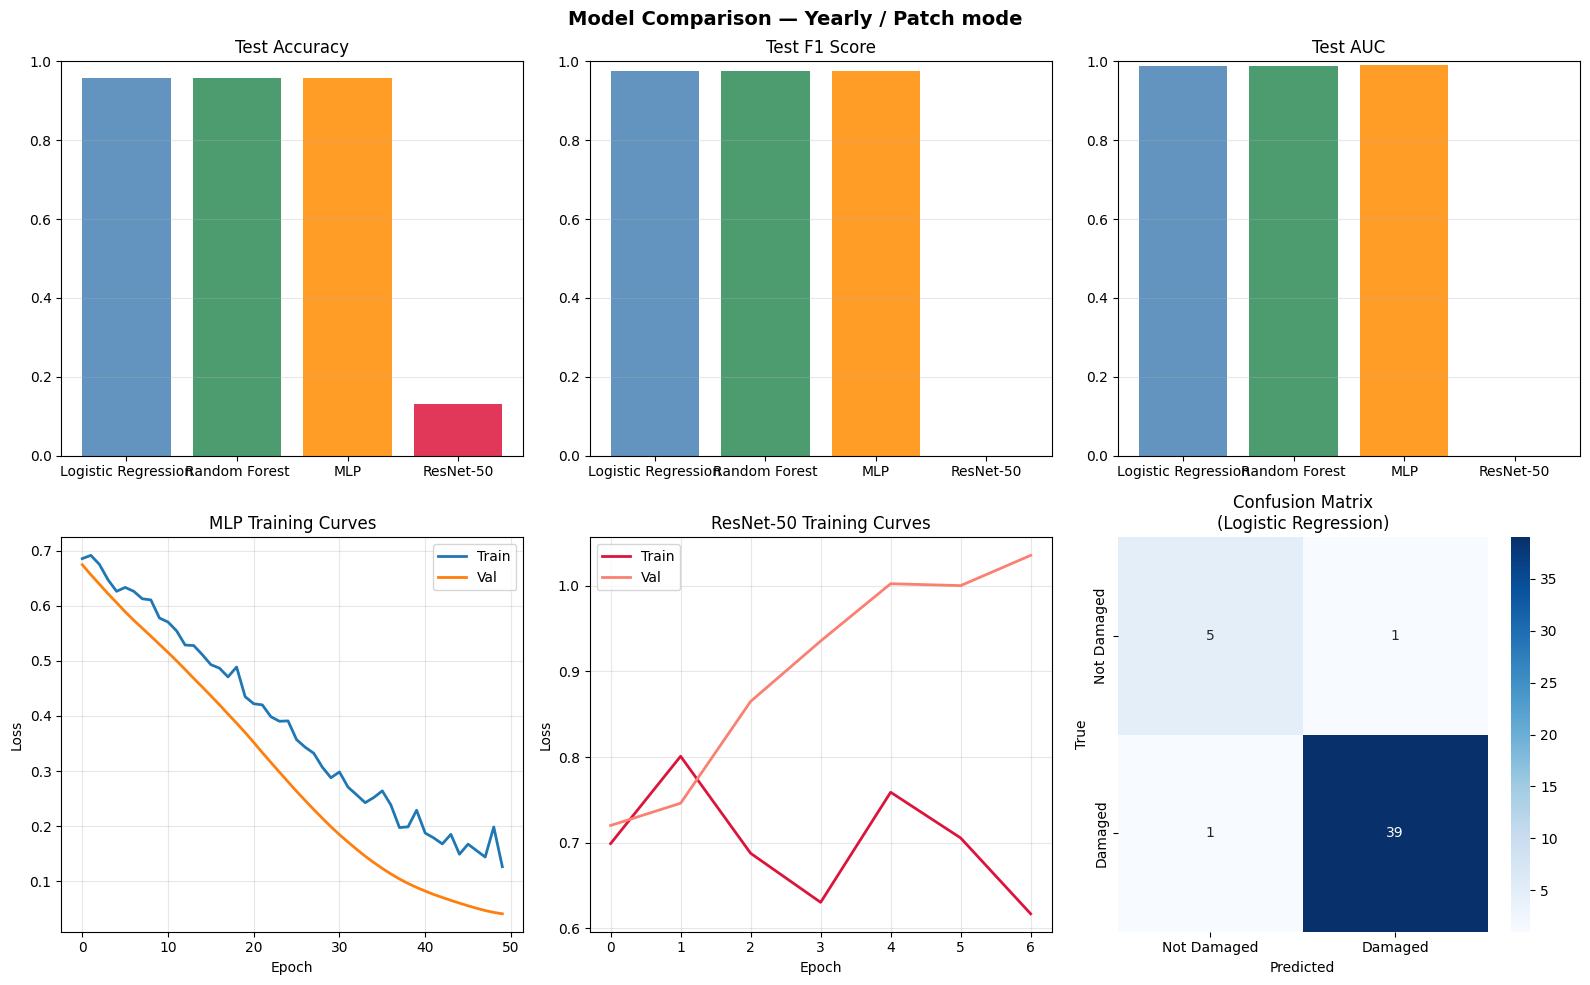

✓ Saved ../results/plots/model_evaluation.png


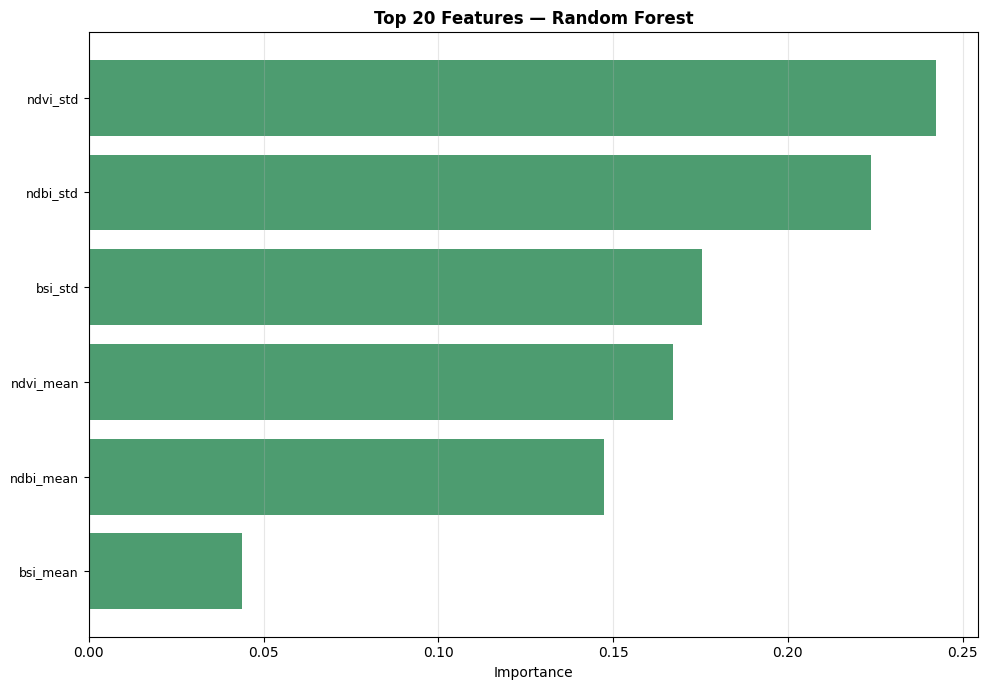

✓ Saved ../results/plots/feature_importance.png


In [99]:
n_models = len(results_df)
colors   = ['steelblue', 'seagreen', 'darkorange', 'crimson'][:n_models]
model_names = results_df['model'].values

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    f'Model Comparison — {TEMPORAL_RES.capitalize()} / {"Patch" if PATCH_MODE else "Scene-level"} mode',
    fontsize=14, fontweight='bold'
)

# 1. Accuracy
axes[0,0].bar(model_names, results_df['test_acc'], color=colors, alpha=0.85)
axes[0,0].set_title('Test Accuracy'); axes[0,0].set_ylim(0, 1)
axes[0,0].grid(True, alpha=0.3, axis='y')

# 2. F1 Score
axes[0,1].bar(model_names, results_df['test_f1'], color=colors, alpha=0.85)
axes[0,1].set_title('Test F1 Score'); axes[0,1].set_ylim(0, 1)
axes[0,1].grid(True, alpha=0.3, axis='y')

# 3. AUC
axes[0,2].bar(model_names, results_df['test_auc'], color=colors, alpha=0.85)
axes[0,2].set_title('Test AUC'); axes[0,2].set_ylim(0, 1)
axes[0,2].grid(True, alpha=0.3, axis='y')

# 4. MLP training curves
axes[1,0].plot(mlp_train_losses, label='Train', linewidth=2)
axes[1,0].plot(mlp_val_losses,   label='Val',   linewidth=2)
axes[1,0].set_title('MLP Training Curves')
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Loss')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

# 5. ResNet-50 training curves (or feature importance if no patches)
if PATCH_MODE and resnet_train_losses:
    axes[1,1].plot(resnet_train_losses, label='Train', linewidth=2, color='crimson')
    axes[1,1].plot(resnet_val_losses,   label='Val',   linewidth=2, color='salmon')
    axes[1,1].set_title('ResNet-50 Training Curves')
    axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Loss')
    axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)
else:
    top10 = feature_importance.head(10)
    axes[1,1].barh(range(len(top10)), top10['importance'].values, color='seagreen', alpha=0.8)
    axes[1,1].set_yticks(range(len(top10)))
    axes[1,1].set_yticklabels(top10['feature'].values, fontsize=8)
    axes[1,1].invert_yaxis()
    axes[1,1].set_title('Top 10 Features (RF)')
    axes[1,1].grid(True, alpha=0.3, axis='x')

# 6. Confusion matrix for best model
if best_model_name == 'Logistic Regression':
    y_pred_best = lr_model.predict(X_test_scaled)
elif best_model_name == 'Random Forest':
    y_pred_best = rf_model.predict(X_test_scaled)
elif best_model_name == 'ResNet-50':
    y_pred_best = y_test_pred_resnet
    y_test      = y_test_labels
else:
    with torch.no_grad():
        y_pred_best = torch.argmax(nn_model(X_test_t), 1).cpu().numpy()

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,2],
            xticklabels=['Not Damaged', 'Damaged'],
            yticklabels=['Not Damaged', 'Damaged'])
axes[1,2].set_title(f'Confusion Matrix\n({best_model_name})')
axes[1,2].set_ylabel('True'); axes[1,2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../results/plots/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved ../results/plots/model_evaluation.png')

# Feature importance (separate plot, always useful)
top20 = feature_importance.head(20)
fig2, ax2 = plt.subplots(figsize=(10, 7))
ax2.barh(range(len(top20)), top20['importance'].values, color='seagreen', alpha=0.85)
ax2.set_yticks(range(len(top20)))
ax2.set_yticklabels(top20['feature'].values, fontsize=9)
ax2.invert_yaxis()
ax2.set_xlabel('Importance')
ax2.set_title('Top 20 Features — Random Forest', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../results/plots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved ../results/plots/feature_importance.png')

## 9. Save Predictions for Notebook 4

In [100]:
print('='*70)
print('Saving Test Predictions for Notebook 4')
print('='*70)

# Use best model to generate probabilities
if best_model_name == 'Logistic Regression':
    proba_best = lr_model.predict_proba(X_test_scaled)[:, 1]
    pred_best  = lr_model.predict(X_test_scaled)
elif best_model_name == 'Random Forest':
    proba_best = rf_model.predict_proba(X_test_scaled)[:, 1]
    pred_best  = rf_model.predict(X_test_scaled)
elif best_model_name == 'ResNet-50':
    proba_best = y_test_proba_resnet
    pred_best  = y_test_pred_resnet
else:
    with torch.no_grad():
        out        = nn_model(X_test_t)
        proba_best = torch.softmax(out, 1)[:, 1].cpu().numpy()
        pred_best  = out.argmax(1).cpu().numpy()

predictions = df_test.copy()
predictions['predicted_damage']   = pred_best
predictions['damage_probability']  = proba_best
predictions['correct_prediction']  = (predictions['damage_label'] == predictions['predicted_damage']).astype(int)
predictions['best_model']          = best_model_name

predictions.to_csv('../results/predictions/test_predictions.csv', index=False)

print(f'  Correct: {predictions["correct_prediction"].sum()}/{len(predictions)}')
print(f'  Accuracy: {predictions["correct_prediction"].mean():.4f}')
print(f'\n  Sample predictions:')
cols = ['city', 'period', 'damage_label', 'predicted_damage', 'damage_probability', 'correct_prediction']
cols = [c for c in cols if c in predictions.columns]
print(predictions[cols].head(10).to_string(index=False))
print('\n✓ Saved ../results/predictions/test_predictions.csv')

Saving Test Predictions for Notebook 4
  Correct: 44/46
  Accuracy: 0.9565

  Sample predictions:
   city      period  damage_label  predicted_damage  damage_probability  correct_prediction
Bakhmut 2021_annual             0                 1            0.644758                   0
Bakhmut 2021_annual             0                 0            0.314617                   1
Bakhmut 2021_annual             0                 0            0.358772                   1
Bakhmut 2021_annual             0                 0            0.196526                   1
Bakhmut 2021_annual             0                 0            0.418845                   1
Bakhmut 2021_annual             0                 0            0.483059                   1
Kharkiv 2023_annual             1                 1            0.919181                   1
Kharkiv 2023_annual             1                 1            0.930563                   1
Kharkiv 2023_annual             1                 1            0.955548   

## 10. Final Summary

In [101]:
print('='*70)
print('MODEL TRAINING COMPLETE')
print('='*70)
print(f'  Mode              : {TEMPORAL_RES} / {"patch" if PATCH_MODE else "scene-level"}')
print(f'  Best model        : {best_model_name}')
print(f'  Test F1           : {best_f1:.4f}')
print(f'  Test Accuracy     : {results_df.loc[best_idx, "test_acc"]:.4f}')
print(f'  Test AUC          : {results_df.loc[best_idx, "test_auc"]:.4f}')
print()
print('Saved files:')
print('  ../models/logistic_regression.pkl')
print('  ../models/random_forest.pkl')
print('  ../models/neural_network.pth  (MLP best weights)')
if PATCH_MODE:
    print('  ../models/resnet50_best.pth')
print('  ../models/feature_cols.json')
print('  ../models/imputer.pkl')
print('  ../models/scaler.pkl')
print('  ../results/metrics/model_comparison.csv')
print('  ../results/predictions/test_predictions.csv')
print('  ../results/plots/model_evaluation.png')
print('  ../results/plots/feature_importance.png')
print()
print('→ Run Notebook 4 for full evaluation and damage maps')

MODEL TRAINING COMPLETE
  Mode              : yearly / patch
  Best model        : Logistic Regression
  Test F1           : 0.9750
  Test Accuracy     : 0.9565
  Test AUC          : 0.9875

Saved files:
  ../models/logistic_regression.pkl
  ../models/random_forest.pkl
  ../models/neural_network.pth  (MLP best weights)
  ../models/resnet50_best.pth
  ../models/feature_cols.json
  ../models/imputer.pkl
  ../models/scaler.pkl
  ../results/metrics/model_comparison.csv
  ../results/predictions/test_predictions.csv
  ../results/plots/model_evaluation.png
  ../results/plots/feature_importance.png

→ Run Notebook 4 for full evaluation and damage maps



---



# Satellite Damage Assessment: Evaluation & Damage Mapping

## Notebook 4 - Model Evaluation & Results

This notebook:
1. Loads trained models and test predictions from Notebook 3
2. Performs deep-dive evaluation (confusion matrices, ROC curves, per-city analysis)
3. Generates damage maps by city and time period
4. Compares predictions with UNOSAT-style ground truth (period-based)
5. Produces final summary report

## 1. Setup & Load Data

In [102]:
import pandas as pd
import numpy as np
import os
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

import torch
import torch.nn as nn
import torchvision.models as tv_models
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

os.makedirs('../results/metrics', exist_ok=True)
os.makedirs('../results/plots', exist_ok=True)
os.makedirs('../results/predictions', exist_ok=True)
os.makedirs('../results/damage_maps', exist_ok=True)

print("="*70)
print("EVALUATION NOTEBOOK: Loading Saved Models & Predictions")
print("="*70)

# ── Load test predictions from Notebook 3 ──────────────────────────────
predictions_path = '../results/predictions/test_predictions.csv'
if not os.path.exists(predictions_path):
    raise FileNotFoundError(
        f"Cannot find {predictions_path}. "
        "Please run Notebook 3 first to generate predictions."
    )

predictions = pd.read_csv(predictions_path)
print(f"\n✓ Loaded test predictions: {len(predictions)} records")

# ── Load full splits for re-evaluation ─────────────────────────────────
df_train = pd.read_csv('../data/splits/train_metadata.csv')
df_val   = pd.read_csv('../data/splits/val_metadata.csv')
df_test  = pd.read_csv('../data/splits/test_metadata.csv')
print(f"\nSplit sizes  →  Train: {len(df_train)}  |  Val: {len(df_val)}  |  Test: {len(df_test)}")

# ── Load model comparison table ─────────────────────────────────────────
comparison_path = '../results/metrics/model_comparison.csv'
if os.path.exists(comparison_path):
    results_df = pd.read_csv(comparison_path)
    best_idx       = results_df['test_f1'].idxmax()
    best_model_name = results_df.loc[best_idx, 'model']
    print(f"\nBest model from Notebook 3: {best_model_name}")
    print(results_df.to_string(index=False))
else:
    print("\n⚠ model_comparison.csv not found – metrics will be recomputed below.")
    results_df = None
    best_model_name = None

EVALUATION NOTEBOOK: Loading Saved Models & Predictions

✓ Loaded test predictions: 46 records

Split sizes  →  Train: 60  |  Val: 12  |  Test: 46

Best model from Notebook 3: Logistic Regression
              model  train_acc  val_acc  test_acc  test_precision  test_recall  test_f1  test_auc
Logistic Regression   0.966667      1.0  0.956522           0.975        0.975    0.975  0.987500
      Random Forest   1.000000      1.0  0.956522           0.975        0.975    0.975  0.987500
                MLP   0.966667      1.0  0.956522           0.975        0.975    0.975  0.991667
          ResNet-50   0.500000      0.0  0.130435           0.000        0.000    0.000  0.000000


## 2. Load & Re-initialise Models

In [103]:
import pickle, json

print("\n" + "="*70)
print("Loading Trained Models")
print("="*70)

# ── Feature columns (must match Notebook 3) ─────────────────────────────
# feature_cols = [c for c in df_train.columns
#                 if c.startswith(('ndvi_', 'ndbi_', 'bsi_', 'damage_',
#                                  'vegetation_', 'urbanization_', 'bare_', 'high_'))]
# print(f"\nFeature columns ({len(feature_cols)}): {feature_cols}")

with open('../models/feature_cols.json', 'r') as f:
    feature_cols = json.load(f)
print(f"✓ Loaded {len(feature_cols)} feature columns from notebook 3")

# Load imputer and scaler fitted in notebook 3
with open('../models/imputer.pkl', 'rb') as f:
    imputer = pickle.load(f)
with open('../models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# ── Extract arrays ───────────────────────────────────────────────────────
X_train = df_train[feature_cols].values.astype(np.float32)
y_train = df_train['damage_label'].values.astype(np.int64)

X_val   = df_val[feature_cols].values.astype(np.float32)
y_val   = df_val['damage_label'].values.astype(np.int64)

# Extract and transform — no fit, just transform
X_test = df_test[feature_cols].values.astype(np.float32)
y_test = df_test['damage_label'].values.astype(np.int64)

# ── Fit scaler on training data ──────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test = imputer.transform(X_test)       # handle NaNs
X_test_scaled = scaler.transform(X_test) # same scaling as training

print(f"✓ X_test_scaled shape: {X_test_scaled.shape}")
print(f"✓ NaNs remaining: {np.isnan(X_test_scaled).sum()}")

# ── Load sklearn models ──────────────────────────────────────────────────
models = {}
for name, path in [('Logistic Regression', '../models/logistic_regression.pkl'),
                   ('Random Forest',       '../models/random_forest.pkl')]:
    if os.path.exists(path):
        with open(path, 'rb') as f:
            models[name] = pickle.load(f)
        print(f"\n✓ Loaded {name}")
    else:
        print(f"\n⚠ {path} not found – skipping")

# ── Re-create and load Neural Network ───────────────────────────────────

class TabularMLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(64, 32),         nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 2)
        )
    def forward(self, x):
        return self.net(x)

nn_path = '../models/neural_network.pth'
if os.path.exists(nn_path):
    # nn_model = DamageClassifier(input_size=X_train_scaled.shape[1])
    # nn_model = DamageClassifier(input_size=len(feature_cols))  # guaranteed to match
    nn_model = TabularMLP(input_size=len(feature_cols))
    nn_model.load_state_dict(torch.load(nn_path, map_location='cpu'))
    nn_model.eval()
    models['Neural Network'] = nn_model
    print(f"\n✓ Loaded Neural Network")
else:
    print(f"\n⚠ {nn_path} not found – skipping")
    
# ── Detect patch mode ────────────────────────────────────────────────
PATCH_MODE = ('patch_id' in df_train.columns and
               os.path.exists('../data/patches/patch_000000.npy'))
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Patch mode: {PATCH_MODE}  |  Device: {DEVICE}')

if PATCH_MODE:
    # ── Rebuild SentinelPatchDataset ────────────────────────────────
    class SentinelPatchDataset(Dataset):
        def __init__(self, df, patch_dir='../data/patches', n_bands=6):
            self.df = df.reset_index(drop=True)
            self.patch_dir = patch_dir
            self.n_bands = n_bands

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            patch = np.load(os.path.join(
                self.patch_dir, f'patch_{int(row["patch_id"]):06d}.npy'
            )).astype(np.float32)

            if patch.shape[2] >= self.n_bands:
                patch = patch[:, :, :self.n_bands]
            else:
                pad = np.zeros((*patch.shape[:2], self.n_bands - patch.shape[2]), dtype=np.float32)
                patch = np.concatenate([patch, pad], axis=2)

            patch = np.nan_to_num(patch, nan=0.0, posinf=1.0, neginf=0.0)
            patch = np.clip(patch / 10000.0, 0.0, 1.0)
            tensor = torch.from_numpy(patch.transpose(2, 0, 1))

            imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            imagenet_std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
            tensor[:3] = (tensor[:3] - imagenet_mean) / imagenet_std

            return tensor, int(row['damage_label'])

    N_BANDS = 6
    test_ds   = SentinelPatchDataset(df_test)
    all_ds    = SentinelPatchDataset(pd.concat([df_train, df_val, df_test], ignore_index=True))
    test_loader_resnet = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)
    all_loader_resnet  = DataLoader(all_ds,  batch_size=32, shuffle=False, num_workers=0)

    # ── Load ResNet-50 ──────────────────────────────────────────────
    resnet_path = '../models/resnet50_best.pth'
    if os.path.exists(resnet_path):
        resnet = tv_models.resnet50(weights=None)
        old_conv = resnet.conv1
        new_conv = nn.Conv2d(N_BANDS, old_conv.out_channels,
                             kernel_size=old_conv.kernel_size,
                             stride=old_conv.stride,
                             padding=old_conv.padding, bias=False)
        resnet.conv1 = new_conv
        in_features  = resnet.fc.in_features
        resnet.fc    = nn.Sequential(nn.Dropout(0.5), nn.Linear(in_features, 2))
        resnet.load_state_dict(torch.load(resnet_path, map_location=DEVICE))
        resnet = resnet.to(DEVICE)
        resnet.eval()
        models['ResNet-50'] = resnet
        print('✓ Loaded ResNet-50')
    else:
        print('⚠ resnet50_best.pth not found – skipping')

print(f"\nModels available: {list(models.keys())}")


Loading Trained Models
✓ Loaded 6 feature columns from notebook 3
✓ X_test_scaled shape: (46, 6)
✓ NaNs remaining: 0

✓ Loaded Logistic Regression

✓ Loaded Random Forest

✓ Loaded Neural Network
Patch mode: True  |  Device: cpu
✓ Loaded ResNet-50

Models available: ['Logistic Regression', 'Random Forest', 'Neural Network', 'ResNet-50']


## 3. Full Metrics & Classification Report

In [104]:
print("\n" + "="*70)
print("Full Classification Reports (Test Set)")
print("="*70)

X_test_t = torch.FloatTensor(X_test_scaled)

all_metrics = []

for name, model in models.items():
    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")

    if name == 'Neural Network':
        with torch.no_grad():
            proba = torch.softmax(model(X_test_t), dim=1)[:, 1].numpy()
            preds = torch.argmax(model(X_test_t), dim=1).numpy()
        y_true = y_test
    elif name == 'ResNet-50' and PATCH_MODE:
        all_preds, all_proba, all_true = [], [], []
        with torch.no_grad():
            for imgs, labels in test_loader_resnet:
                imgs = imgs.to(DEVICE)
                out  = model(imgs)
                all_preds.append(out.argmax(1).cpu().numpy())
                all_proba.append(torch.softmax(out, 1)[:, 1].cpu().numpy())
                all_true.append(labels.numpy())
        preds  = np.concatenate(all_preds)
        proba  = np.concatenate(all_proba)
        y_true = np.concatenate(all_true)
    else:
        proba  = model.predict_proba(X_test_scaled)[:, 1]
        preds  = model.predict(X_test_scaled)
        y_true = y_test

    print(classification_report(y_test, preds,
                                target_names=['Not Damaged', 'Damaged']))

    metrics = {
        'model':          name,
        'accuracy':       accuracy_score(y_test, preds),
        'precision':      precision_score(y_test, preds, zero_division=0),
        'recall':         recall_score(y_test, preds, zero_division=0),
        'f1':             f1_score(y_test, preds, zero_division=0),
        'auc_roc':        roc_auc_score(y_test, proba),
        'avg_precision':  average_precision_score(y_test, proba),
    }
    all_metrics.append(metrics)
    print(f"  AUC-ROC:           {metrics['auc_roc']:.4f}")
    print(f"  Avg Precision:     {metrics['avg_precision']:.4f}")

metrics_df = pd.DataFrame(all_metrics)
metrics_df.to_csv('../results/metrics/full_evaluation.csv', index=False)
print(f"\n\n✓ Full metrics saved to ../results/metrics/full_evaluation.csv")
print(f"\n{metrics_df.to_string(index=False)}")


Full Classification Reports (Test Set)

──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
              precision    recall  f1-score   support

 Not Damaged       0.83      0.83      0.83         6
     Damaged       0.97      0.97      0.97        40

    accuracy                           0.96        46
   macro avg       0.90      0.90      0.90        46
weighted avg       0.96      0.96      0.96        46

  AUC-ROC:           0.9875
  Avg Precision:     0.9983

──────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────
              precision    recall  f1-score   support

 Not Damaged       0.83      0.83      0.83         6
     Damaged       0.97      0.97      0.97        40

    accuracy                           0.96        46
   macro avg       0.90      0.90      0.90        46
weighted avg       0.96      0.96      0.96        46

  AUC-

## 4. Confusion Matrices


Confusion Matrices


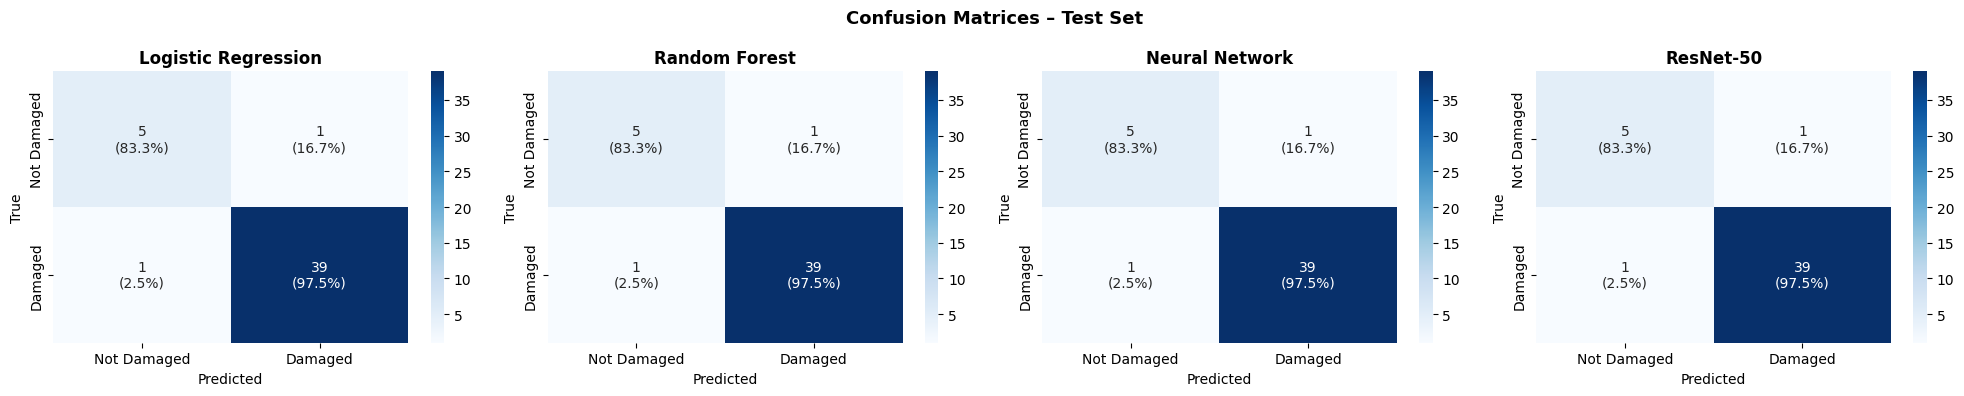


✓ Saved ../results/plots/confusion_matrices.png


In [105]:
print("\n" + "="*70)
print("Confusion Matrices")
print("="*70)

n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, models.items()):
    if name == 'Neural Network':
        with torch.no_grad():
            preds = torch.argmax(model(X_test_t), dim=1).numpy()
    elif name == 'ResNet-50' and PATCH_MODE:
        proba  = np.concatenate(all_proba)
    else:
        preds = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, preds)

    # Percentage annotation
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    labels = np.array([[f"{v}\n({p:.1f}%)" for v, p in zip(row_v, row_p)]
                       for row_v, row_p in zip(cm, cm_pct)])

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax,
                xticklabels=['Not Damaged', 'Damaged'],
                yticklabels=['Not Damaged', 'Damaged'])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion Matrices – Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Saved ../results/plots/confusion_matrices.png")

## 5. ROC & Precision-Recall Curves


ROC & Precision-Recall Curves


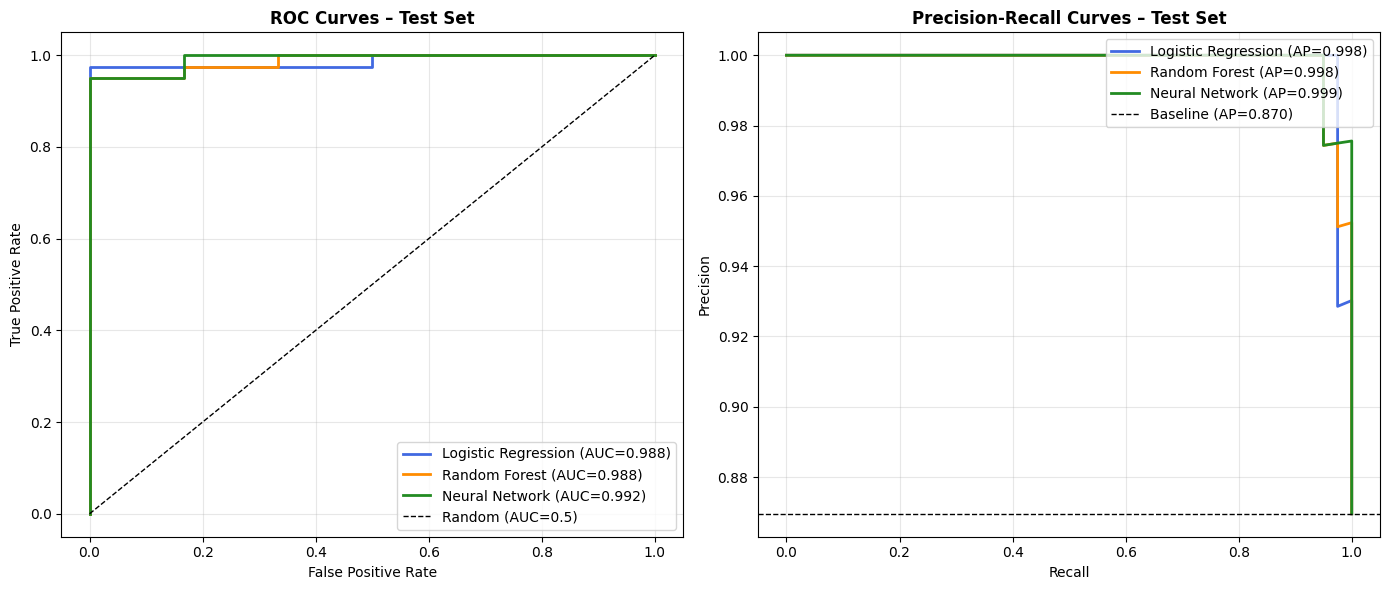


✓ Saved ../results/plots/roc_pr_curves.png


In [106]:
print("\n" + "="*70)
print("ROC & Precision-Recall Curves")
print("="*70)

colors = ['royalblue', 'darkorange', 'forestgreen']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for (name, model), color in zip(models.items(), colors):
    if name == 'Neural Network':
        with torch.no_grad():
            proba = torch.softmax(model(X_test_t), dim=1)[:, 1].numpy()
    elif name == 'ResNet-50' and PATCH_MODE:
        proba  = np.concatenate(all_proba)
    else:
        proba = model.predict_proba(X_test_scaled)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc         = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, linewidth=2)

    # Precision-Recall
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap           = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.3f})", color=color, linewidth=2)

# ROC
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves – Test Set', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# PR
baseline = y_test.mean()
axes[1].axhline(y=baseline, color='k', linestyle='--', linewidth=1,
                label=f'Baseline (AP={baseline:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves – Test Set', fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/plots/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Saved ../results/plots/roc_pr_curves.png")

## 6. Per-City Performance Analysis

In [107]:
print("\n" + "="*70)
print("Per-City Performance Analysis")
print("="*70)

# Identify best model by F1
best_row        = metrics_df.loc[metrics_df['f1'].idxmax()]
best_model_name = best_row['model']
best_model      = models[best_model_name]

print(f"\nUsing best model: {best_model_name} (F1={best_row['f1']:.4f})")

# Generate predictions on FULL dataset (train+val+test) for city maps
df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
y_all  = df_all['damage_label'].values

best_row        = metrics_df.loc[metrics_df['f1'].idxmax()]
best_model_name = best_row['model']
best_model      = models[best_model_name]

if best_model_name == 'Neural Network':
    X_all = imputer.transform(df_all[feature_cols].values.astype(np.float32))
    X_all_scaled = scaler.transform(X_all)
    with torch.no_grad():
        out       = best_model(torch.FloatTensor(X_all_scaled))
        preds_all = out.argmax(1).numpy()
        proba_all = torch.softmax(out, 1)[:, 1].numpy()

elif best_model_name == 'ResNet-50' and PATCH_MODE:
    all_preds, all_proba = [], []
    with torch.no_grad():
        for imgs, _ in all_loader_resnet:
            imgs = imgs.to(DEVICE)
            out  = best_model(imgs)
            all_preds.append(out.argmax(1).cpu().numpy())
            all_proba.append(torch.softmax(out, 1)[:, 1].cpu().numpy())
    preds_all = np.concatenate(all_preds)
    proba_all = np.concatenate(all_proba)

else:
    X_all = imputer.transform(df_all[feature_cols].values.astype(np.float32))
    X_all_scaled = scaler.transform(X_all)
    preds_all = best_model.predict(X_all_scaled)
    proba_all = best_model.predict_proba(X_all_scaled)[:, 1]

df_all['predicted_damage']   = preds_all
df_all['damage_probability'] = proba_all

# ── Per-city metrics ─────────────────────────────────────────────────────
city_metrics = []
for city in df_all['city'].unique():
    subset = df_all[df_all['city'] == city]
    yt  = subset['damage_label'].values
    yp  = subset['predicted_damage'].values
    ypr = subset['damage_probability'].values

    if len(np.unique(yt)) < 2:
        auc = float('nan')
    else:
        auc = roc_auc_score(yt, ypr)

    city_metrics.append({
        'city':        city,
        'n_scenes':    len(subset),
        'n_damaged':   int(yt.sum()),
        'accuracy':    accuracy_score(yt, yp),
        'precision':   precision_score(yt, yp, zero_division=0),
        'recall':      recall_score(yt, yp, zero_division=0),
        'f1':          f1_score(yt, yp, zero_division=0),
        'auc_roc':     auc,
    })

city_df = pd.DataFrame(city_metrics)
city_df.to_csv('../results/metrics/per_city_metrics.csv', index=False)

print(f"\nPer-City Results:")
print(city_df.to_string(index=False))
print(f"\n✓ Saved ../results/metrics/per_city_metrics.csv")


Per-City Performance Analysis

Using best model: Logistic Regression (F1=0.9750)

Per-City Results:
    city  n_scenes  n_damaged  accuracy  precision   recall       f1  auc_roc
 Kharkiv        51         48  1.000000   1.000000 1.000000 1.000000 1.000000
Mariupol        49         33  0.938776   0.941176 0.969697 0.955224 0.982955
 Bakhmut        18         12  0.944444   0.923077 1.000000 0.960000 1.000000

✓ Saved ../results/metrics/per_city_metrics.csv


## 7. Damage Maps by City


Damage Maps by City
Using 'period' as the x-axis for damage maps


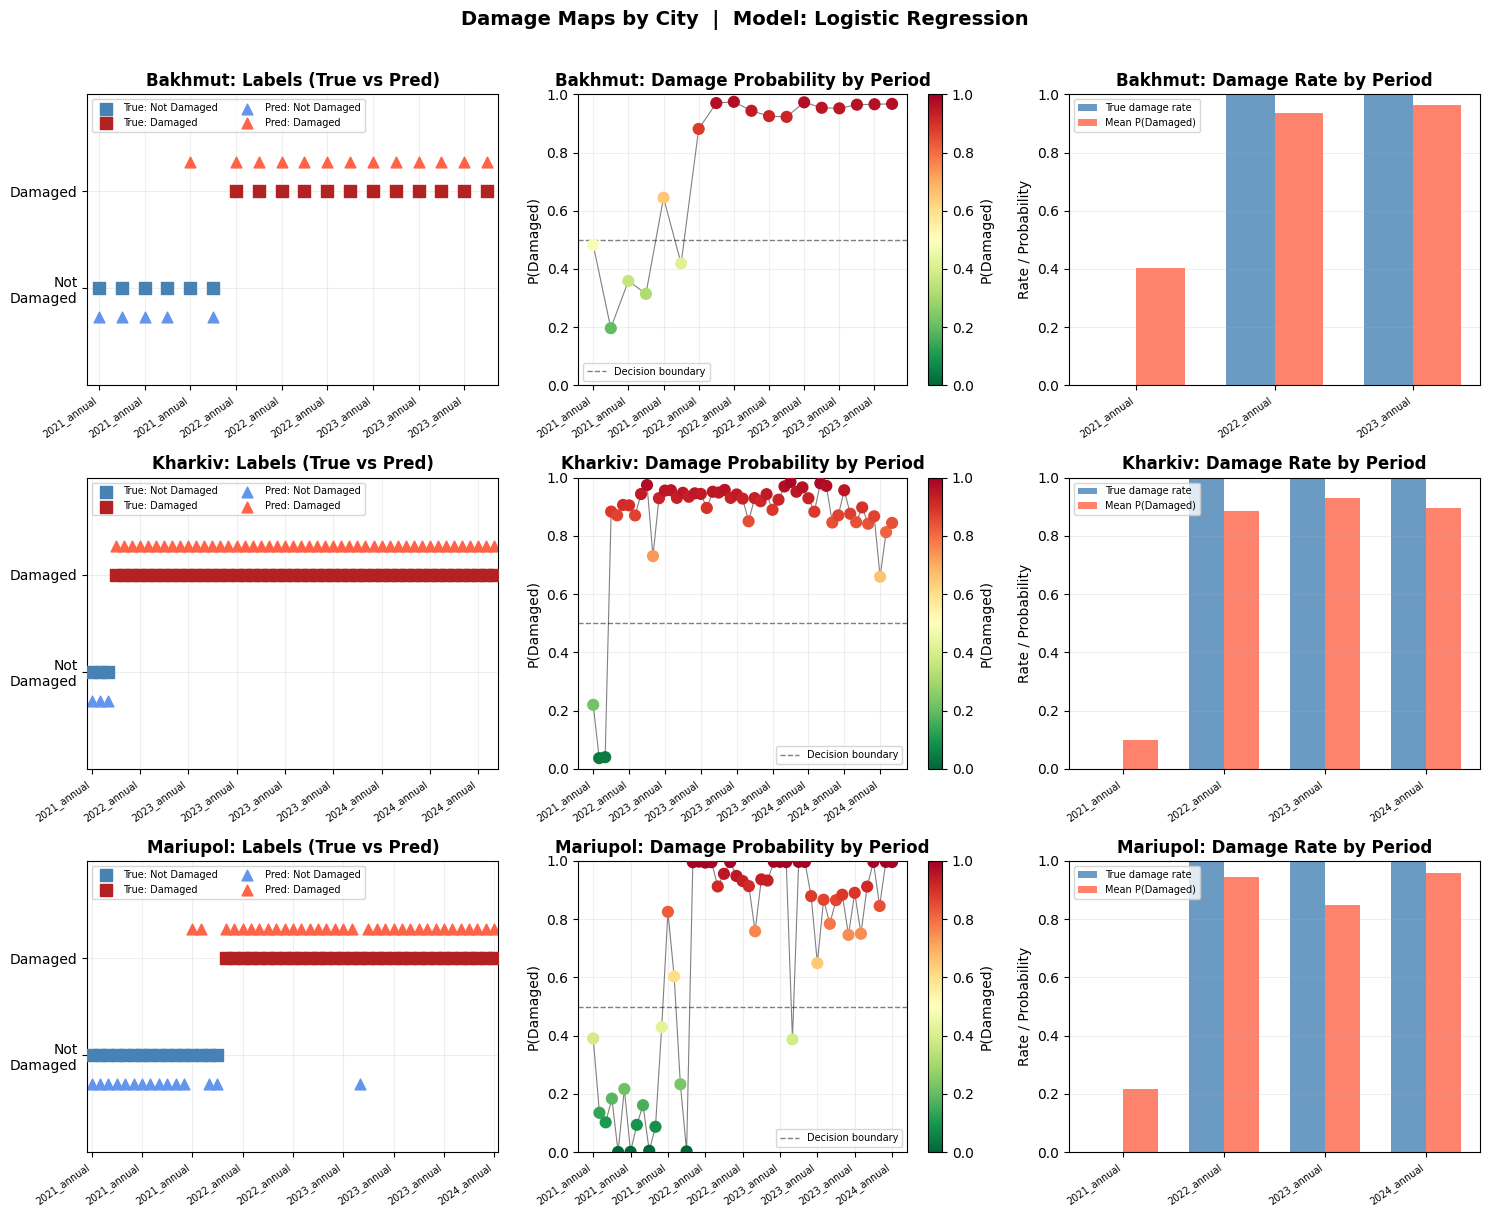


✓ Saved ../results/damage_maps/city_damage_maps.png


In [108]:
print("\n" + "="*70)
print("Damage Maps by City")
print("="*70)

# ── Detect the ordering column (period preferred, date as fallback) ──────
if 'period' in df_all.columns:
    order_col = 'period'
elif 'date' in df_all.columns:
    order_col = 'date'
else:
    # Use row index order – create a proxy column
    df_all['_row_order'] = np.arange(len(df_all))
    order_col = '_row_order'

print(f"Using '{order_col}' as the x-axis for damage maps")

cities = sorted(df_all['city'].unique())
n_rows = len(cities)

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

cmap_prob = plt.cm.RdYlGn_r   # green=safe, red=damaged

for row_i, city in enumerate(cities):
    subset = df_all[df_all['city'] == city].copy()
    subset = subset.sort_values(order_col)

    x_labels = subset[order_col].astype(str).values
    true_lab  = subset['damage_label'].values
    pred_lab  = subset['predicted_damage'].values
    prob      = subset['damage_probability'].values
    x = np.arange(len(x_labels))

    # ── Panel 1: True vs Predicted labels ────────────────────────────────
    ax1 = axes[row_i, 0]
    ax1.scatter(x[true_lab == 0], np.zeros((true_lab == 0).sum()),
                color='steelblue', marker='s', s=80, label='True: Not Damaged', zorder=3)
    ax1.scatter(x[true_lab == 1], np.ones((true_lab == 1).sum()),
                color='firebrick', marker='s', s=80, label='True: Damaged', zorder=3)
    ax1.scatter(x[pred_lab == 0], np.full((pred_lab == 0).sum(), -0.3),
                color='cornflowerblue', marker='^', s=60, label='Pred: Not Damaged', zorder=2)
    ax1.scatter(x[pred_lab == 1], np.full((pred_lab == 1).sum(), 1.3),
                color='tomato', marker='^', s=60, label='Pred: Damaged', zorder=2)
    ax1.set_xlim(-0.5, len(x_labels) - 0.5)
    ax1.set_ylim(-1, 2)
    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(['Not\nDamaged', 'Damaged'])
    ax1.set_title(f"{city}: Labels (True vs Pred)", fontweight='bold')
    tick_step = max(1, len(x) // 8)
    ax1.set_xticks(x[::tick_step])
    ax1.set_xticklabels(x_labels[::tick_step], rotation=35, ha='right', fontsize=7)
    ax1.legend(fontsize=7, ncol=2, loc='upper left')
    ax1.grid(True, alpha=0.2)

    # ── Panel 2: Damage probability ──────────────────────────────────────
    ax2 = axes[row_i, 1]
    sc = ax2.scatter(x, prob, c=prob, cmap=cmap_prob, vmin=0, vmax=1, s=60, zorder=3)
    ax2.plot(x, prob, color='grey', linewidth=0.8, zorder=2)
    ax2.axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Decision boundary')
    ax2.set_ylim(0, 1)
    ax2.set_ylabel('P(Damaged)')
    ax2.set_title(f"{city}: Damage Probability by {order_col.title()}", fontweight='bold')
    ax2.set_xticks(x[::tick_step])
    ax2.set_xticklabels(x_labels[::tick_step], rotation=35, ha='right', fontsize=7)
    ax2.legend(fontsize=7)
    ax2.grid(True, alpha=0.2)
    plt.colorbar(sc, ax=ax2, label='P(Damaged)')

    # ── Panel 3: Aggregated damage rate per period ───────────────────────
    ax3 = axes[row_i, 2]
    period_agg = subset.groupby(order_col, sort=True).agg(
        mean_prob=('damage_probability', 'mean'),
        true_rate=('damage_label',       'mean')
    ).reset_index()
    xp    = np.arange(len(period_agg))
    bar_w = 0.35
    ax3.bar(xp - bar_w/2, period_agg['true_rate'], bar_w,
            color='steelblue', alpha=0.8, label='True damage rate')
    ax3.bar(xp + bar_w/2, period_agg['mean_prob'], bar_w,
            color='tomato', alpha=0.8, label='Mean P(Damaged)')
    ax3.set_xticks(xp)
    ax3.set_xticklabels(period_agg[order_col].astype(str), rotation=35, ha='right', fontsize=7)
    ax3.set_ylim(0, 1)
    ax3.set_ylabel('Rate / Probability')
    ax3.set_title(f"{city}: Damage Rate by {order_col.title()}", fontweight='bold')
    ax3.legend(fontsize=7)
    ax3.grid(True, alpha=0.2, axis='y')

plt.suptitle(f'Damage Maps by City  |  Model: {best_model_name}',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/damage_maps/city_damage_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Saved ../results/damage_maps/city_damage_maps.png")

## 8. UNOSAT-Style Ground Truth Comparison


UNOSAT-Style Ground Truth Comparison

City × Period Comparison (True Rate vs Model Rate):
    city      period  unosat_rate  model_rate  n_scenes  rate_diff  abs_diff
 Bakhmut 2021_annual          0.0    0.402763         6   0.402763  0.402763
 Bakhmut 2022_annual          1.0    0.936114         6  -0.063886  0.063886
 Bakhmut 2023_annual          1.0    0.962602         6  -0.037398  0.037398
 Kharkiv 2021_annual          0.0    0.098507         3   0.098507  0.098507
 Kharkiv 2022_annual          1.0    0.885551         8  -0.114449  0.114449
 Kharkiv 2023_annual          1.0    0.931630        20  -0.068370  0.068370
 Kharkiv 2024_annual          1.0    0.894106        20  -0.105894  0.105894
Mariupol 2021_annual          0.0    0.216701        16   0.216701  0.216701
Mariupol 2022_annual          1.0    0.943936        13  -0.056064  0.056064
Mariupol 2023_annual          1.0    0.850007        16  -0.149993  0.149993
Mariupol 2024_annual          1.0    0.958976         4  -0.04

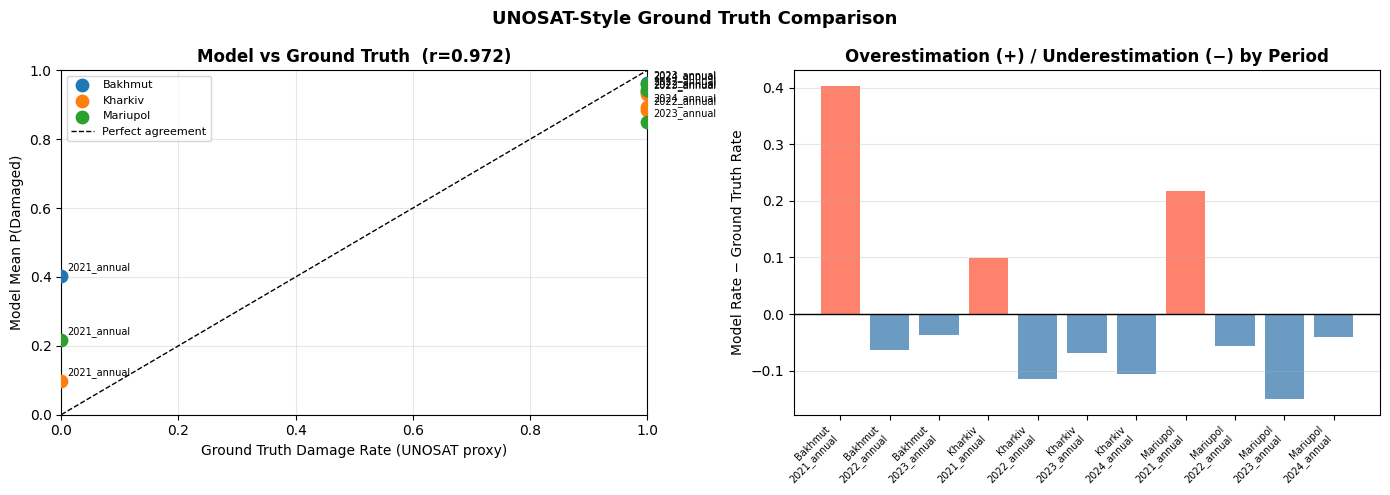


✓ Saved ../results/plots/unosat_comparison.png
✓ Saved ../results/metrics/unosat_comparison.csv


In [109]:
print("\n" + "="*70)
print("UNOSAT-Style Ground Truth Comparison")
print("="*70)

# ── Build UNOSAT proxy from the dataset labels ───────────────────────────
# In this project the ground truth labels are period-based:
#   pre-conflict  (2021)       → damage_label = 0
#   conflict/post (2022-2024)  → damage_label = 1
# We treat the per-city, per-period true damage rate as the UNOSAT reference.

if 'period' in df_all.columns:
    gt_comparison = df_all.groupby(['city', 'period']).agg(
        unosat_rate   = ('damage_label',       'mean'),
        model_rate    = ('damage_probability',  'mean'),
        n_scenes      = ('damage_label',        'count')
    ).reset_index()

    gt_comparison['rate_diff']   = gt_comparison['model_rate'] - gt_comparison['unosat_rate']
    gt_comparison['abs_diff']    = gt_comparison['rate_diff'].abs()

    print(f"\nCity × Period Comparison (True Rate vs Model Rate):")
    print(gt_comparison.to_string(index=False))

    # ── Correlation ──────────────────────────────────────────────────────
    corr = gt_comparison[['unosat_rate', 'model_rate']].corr().iloc[0, 1]
    mae  = gt_comparison['abs_diff'].mean()
    print(f"\nCorrelation (model vs ground truth): {corr:.4f}")
    print(f"Mean Absolute Error in damage rate:  {mae:.4f}")

    # ── Scatter plot ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter
    for city in gt_comparison['city'].unique():
        sub = gt_comparison[gt_comparison['city'] == city]
        axes[0].scatter(sub['unosat_rate'], sub['model_rate'], s=80, label=city, zorder=3)
        for _, r in sub.iterrows():
            axes[0].annotate(r['period'], (r['unosat_rate'], r['model_rate']),
                             textcoords='offset points', xytext=(4, 4), fontsize=7)

    axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect agreement')
    axes[0].set_xlabel('Ground Truth Damage Rate (UNOSAT proxy)')
    axes[0].set_ylabel('Model Mean P(Damaged)')
    axes[0].set_title(f'Model vs Ground Truth  (r={corr:.3f})', fontweight='bold')
    axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # Bar: absolute error per city-period
    gt_comparison['label'] = gt_comparison['city'] + '\n' + gt_comparison['period']
    bar_colors = ['tomato' if d > 0 else 'steelblue' for d in gt_comparison['rate_diff']]
    axes[1].bar(range(len(gt_comparison)), gt_comparison['rate_diff'], color=bar_colors, alpha=0.8)
    axes[1].axhline(0, color='black', linewidth=1)
    axes[1].set_xticks(range(len(gt_comparison)))
    axes[1].set_xticklabels(gt_comparison['label'], rotation=45, ha='right', fontsize=7)
    axes[1].set_ylabel('Model Rate − Ground Truth Rate')
    axes[1].set_title('Overestimation (+) / Underestimation (−) by Period', fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.suptitle('UNOSAT-Style Ground Truth Comparison', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../results/plots/unosat_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✓ Saved ../results/plots/unosat_comparison.png")

    gt_comparison.to_csv('../results/metrics/unosat_comparison.csv', index=False)
    print("✓ Saved ../results/metrics/unosat_comparison.csv")

else:
    print("\n⚠ No 'period' column found in dataset – skipping UNOSAT comparison.")
    print("  Ensure Notebook 2 assigns a 'period' column (e.g. pre_conflict / conflict / post_conflict).")

## 9. Spectral Index Analysis (Post-Conflict Signatures)


Spectral Index Analysis (Damaged vs Undamaged)
  NDVI   Not Damaged mean: 0.1969  Damaged mean: 0.1848   Δ=-0.0120
  NDBI   Not Damaged mean: 0.0066  Damaged mean: 0.0270   Δ=0.0204
  BSI    Not Damaged mean: 0.0612  Damaged mean: 0.0280   Δ=-0.0332


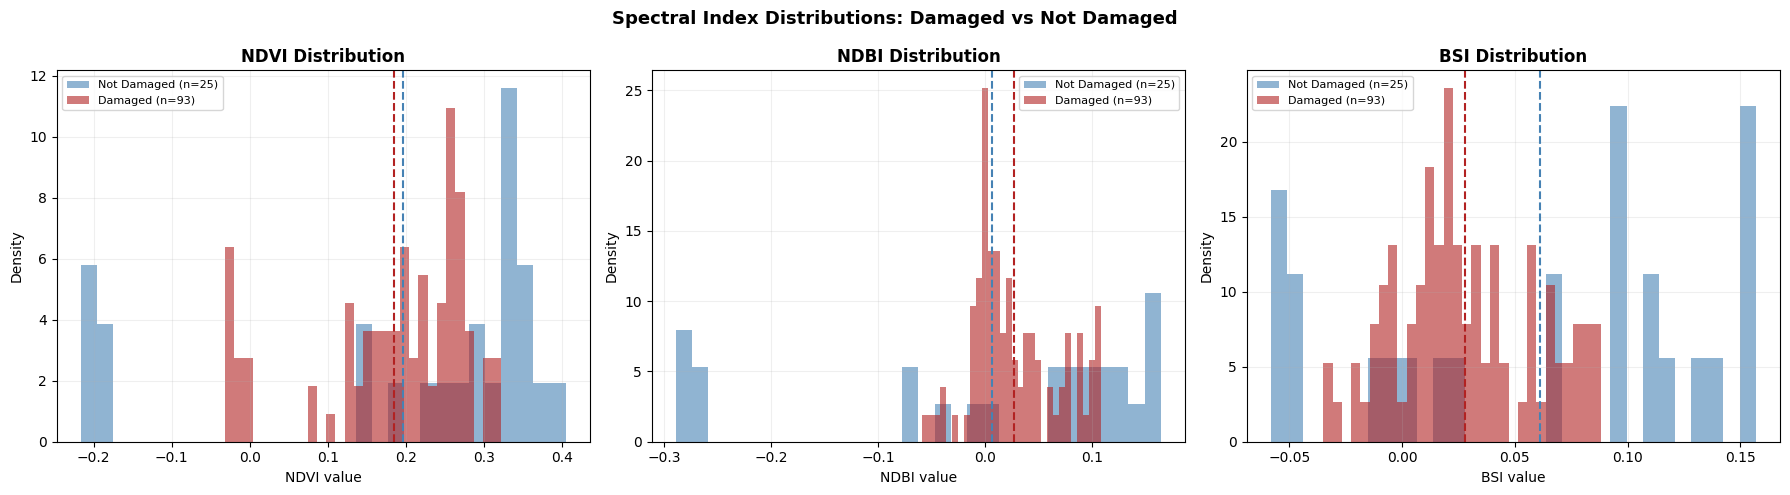


✓ Saved ../results/plots/spectral_index_analysis.png


In [110]:
print("\n" + "="*70)
print("Spectral Index Analysis (Damaged vs Undamaged)")
print("="*70)

# Show how spectral indices differ between damaged and undamaged observations
index_prefixes = ['ndvi_', 'ndbi_', 'bsi_']
index_groups = {prefix.rstrip('_'): [c for c in feature_cols if c.startswith(prefix)]
                for prefix in index_prefixes}
index_groups = {k: v for k, v in index_groups.items() if v}  # drop empty

if not index_groups:
    print("\n⚠ No spectral index columns detected – check feature naming in Notebook 2.")
else:
    n_idx  = len(index_groups)
    fig, axes = plt.subplots(1, n_idx, figsize=(6 * n_idx, 5))
    if n_idx == 1:
        axes = [axes]

    for ax, (idx_name, cols) in zip(axes, index_groups.items()):
        # Use mean across statistics columns for each index
        df_all[f'{idx_name}_mean_feat'] = df_all[cols].mean(axis=1)
        damaged     = df_all[df_all['damage_label'] == 1][f'{idx_name}_mean_feat'].dropna()
        not_damaged = df_all[df_all['damage_label'] == 0][f'{idx_name}_mean_feat'].dropna()

        ax.hist(not_damaged, bins=30, alpha=0.6, color='steelblue',
                density=True, label=f'Not Damaged (n={len(not_damaged)})')
        ax.hist(damaged, bins=30, alpha=0.6, color='firebrick',
                density=True, label=f'Damaged (n={len(damaged)})')
        ax.axvline(not_damaged.mean(), color='steelblue', linestyle='--', linewidth=1.5)
        ax.axvline(damaged.mean(),     color='firebrick',  linestyle='--', linewidth=1.5)
        ax.set_xlabel(f'{idx_name.upper()} value')
        ax.set_ylabel('Density')
        ax.set_title(f'{idx_name.upper()} Distribution', fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.2)
        print(f"  {idx_name.upper():5s}  Not Damaged mean: {not_damaged.mean():.4f} "
              f" Damaged mean: {damaged.mean():.4f}  "
              f" Δ={damaged.mean()-not_damaged.mean():.4f}")

    plt.suptitle('Spectral Index Distributions: Damaged vs Not Damaged',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../results/plots/spectral_index_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✓ Saved ../results/plots/spectral_index_analysis.png")

## 10. Threshold Sensitivity Analysis


Threshold Sensitivity Analysis (Best Model)

Optimal threshold (max F1): 0.50
  Precision: 0.9750
  Recall:    0.9750
  F1:        0.9750


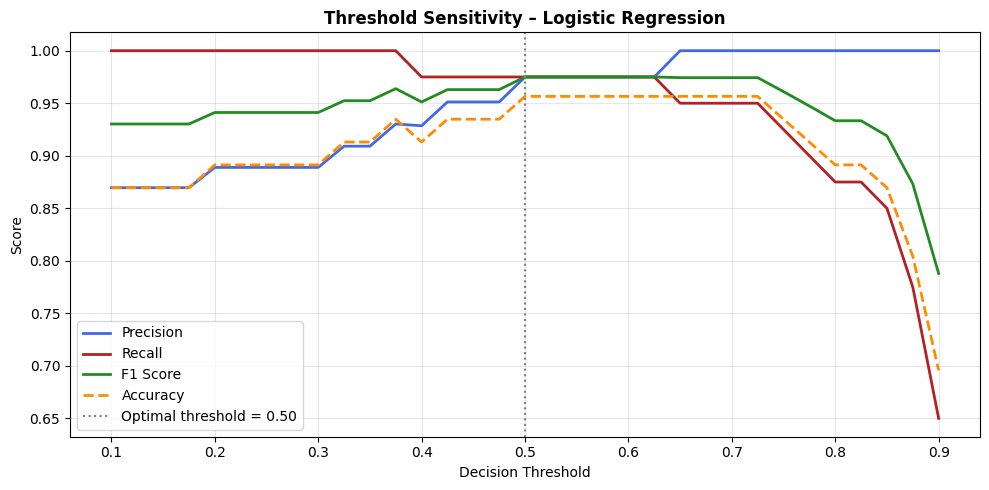


✓ Saved ../results/plots/threshold_sensitivity.png


In [111]:
print("\n" + "="*70)
print("Threshold Sensitivity Analysis (Best Model)")
print("="*70)

if best_model_name == 'Neural Network':
    with torch.no_grad():
        proba_test = torch.softmax(best_model(X_test_t), dim=1)[:, 1].numpy()
elif best_model_name == 'ResNet-50' and PATCH_MODE:
    proba_test = np.concatenate(all_proba)
else:
    proba_test = best_model.predict_proba(X_test_scaled)[:, 1]

thresholds = np.linspace(0.1, 0.9, 33)
thresh_records = []
for t in thresholds:
    yp = (proba_test >= t).astype(int)
    thresh_records.append({
        'threshold': t,
        'precision': precision_score(y_test, yp, zero_division=0),
        'recall':    recall_score(y_test, yp,    zero_division=0),
        'f1':        f1_score(y_test, yp,        zero_division=0),
        'accuracy':  accuracy_score(y_test, yp),
    })

thresh_df = pd.DataFrame(thresh_records)
best_t_row = thresh_df.loc[thresh_df['f1'].idxmax()]
print(f"\nOptimal threshold (max F1): {best_t_row['threshold']:.2f}")
print(f"  Precision: {best_t_row['precision']:.4f}")
print(f"  Recall:    {best_t_row['recall']:.4f}")
print(f"  F1:        {best_t_row['f1']:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', linewidth=2, color='royalblue')
ax.plot(thresh_df['threshold'], thresh_df['recall'],    label='Recall',    linewidth=2, color='firebrick')
ax.plot(thresh_df['threshold'], thresh_df['f1'],        label='F1 Score',  linewidth=2, color='forestgreen')
ax.plot(thresh_df['threshold'], thresh_df['accuracy'],  label='Accuracy',  linewidth=2, color='darkorange', linestyle='--')
ax.axvline(best_t_row['threshold'], color='grey', linestyle=':', linewidth=1.5,
           label=f"Optimal threshold = {best_t_row['threshold']:.2f}")
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Threshold Sensitivity – {best_model_name}', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/plots/threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Saved ../results/plots/threshold_sensitivity.png")

## 11. Final Summary Report

In [112]:
print("\n" + "="*70)
print("FINAL EVALUATION SUMMARY")
print("="*70)

best_metrics = metrics_df.loc[metrics_df['f1'].idxmax()]

summary = {
    'best_model':            best_model_name,
    'test_accuracy':         float(round(best_metrics['accuracy'],  4)),
    'test_precision':        float(round(best_metrics['precision'], 4)),
    'test_recall':           float(round(best_metrics['recall'],    4)),
    'test_f1':               float(round(best_metrics['f1'],        4)),
    'test_auc_roc':          float(round(best_metrics['auc_roc'],   4)),
    'optimal_threshold':     float(round(best_t_row['threshold'],   2)),
    'n_train':               int(len(df_train)),
    'n_val':                 int(len(df_val)),
    'n_test':                int(len(df_test)),
    'n_features':            int(len(feature_cols)),
    'cities_evaluated':      sorted(df_all['city'].unique().tolist()),
}

with open('../results/metrics/final_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\n  Best Model:          {summary['best_model']}")
print(f"  Test Accuracy:       {summary['test_accuracy']}")
print(f"  Test Precision:      {summary['test_precision']}")
print(f"  Test Recall:         {summary['test_recall']}")
print(f"  Test F1 Score:       {summary['test_f1']}")
print(f"  Test AUC-ROC:        {summary['test_auc_roc']}")
print(f"  Optimal Threshold:   {summary['optimal_threshold']}")
print(f"  Features used:       {summary['n_features']}")
print(f"  Cities evaluated:    {', '.join(summary['cities_evaluated'])}")

print(f"\n  Output Files:")
outputs = [
    '../results/metrics/full_evaluation.csv',
    '../results/metrics/per_city_metrics.csv',
    '../results/metrics/unosat_comparison.csv',
    '../results/metrics/final_summary.json',
    '../results/plots/confusion_matrices.png',
    '../results/plots/roc_pr_curves.png',
    '../results/plots/unosat_comparison.png',
    '../results/plots/spectral_index_analysis.png',
    '../results/plots/threshold_sensitivity.png',
    '../results/damage_maps/city_damage_maps.png',
]
for path in outputs:
    status = '✓' if os.path.exists(path) else '⚠ missing'
    print(f"    {status}  {path}")

print(f"\n" + "="*70)
print("✓ EVALUATION PIPELINE COMPLETE!")
print("="*70)


FINAL EVALUATION SUMMARY

  Best Model:          Logistic Regression
  Test Accuracy:       0.9565
  Test Precision:      0.975
  Test Recall:         0.975
  Test F1 Score:       0.975
  Test AUC-ROC:        0.9875
  Optimal Threshold:   0.5
  Features used:       6
  Cities evaluated:    Bakhmut, Kharkiv, Mariupol

  Output Files:
    ✓  ../results/metrics/full_evaluation.csv
    ✓  ../results/metrics/per_city_metrics.csv
    ✓  ../results/metrics/unosat_comparison.csv
    ✓  ../results/metrics/final_summary.json
    ✓  ../results/plots/confusion_matrices.png
    ✓  ../results/plots/roc_pr_curves.png
    ✓  ../results/plots/unosat_comparison.png
    ✓  ../results/plots/spectral_index_analysis.png
    ✓  ../results/plots/threshold_sensitivity.png
    ✓  ../results/damage_maps/city_damage_maps.png

✓ EVALUATION PIPELINE COMPLETE!
